In [146]:
#pip install kagglehub

In [147]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivachandel/kc-house-data")

print("Path to dataset files:", path)

Path to dataset files: /Users/sarahivillegas/.cache/kagglehub/datasets/shivachandel/kc-house-data/versions/1


In [148]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('kc_house_data.csv')

In [149]:
df.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.00,3,1.00,1180,5650,1.00,0,0,...,7,1180.00,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,538000.00,3,2.25,2570,7242,2.00,0,0,...,7,2170.00,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,180000.00,2,1.00,770,10000,1.00,0,0,...,6,770.00,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,604000.00,4,3.00,1960,5000,1.00,0,0,...,7,1050.00,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,510000.00,3,2.00,1680,8080,1.00,0,0,...,8,1680.00,0,1987,0,98074,47.62,-122.05,1800,7503


In [150]:
df.tail(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.00,3,2.50,1530,1131,3.00,0,0,...,8,1530.00,0,2009,0,98103,47.70,-122.35,1530,1509
21609,6600060120,20150223T000000,400000.00,4,2.50,2310,5813,2.00,0,0,...,8,2310.00,0,2014,0,98146,47.51,-122.36,1830,7200
21610,1523300141,20140623T000000,402101.00,2,0.75,1020,1350,2.00,0,0,...,7,1020.00,0,2009,0,98144,47.59,-122.30,1020,2007
21611,291310100,20150116T000000,400000.00,3,2.50,1600,2388,2.00,0,0,...,8,1600.00,0,2004,0,98027,47.53,-122.07,1410,1287
21612,1523300157,20141015T000000,325000.00,2,0.75,1020,1076,2.00,0,0,...,7,1020.00,0,2008,0,98144,47.59,-122.30,1020,1357


In [151]:
df.sample(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
11030,6730700260,20150313T000000,235000.00,2,1.00,860,10500,1.00,0,0,...,6,860.00,0,1943,0,98024,47.57,-121.89,950,10500
17408,8673400190,20140723T000000,557000.00,3,2.50,1630,1587,3.00,0,0,...,8,1630.00,0,2004,0,98107,47.67,-122.39,1500,1527
9149,369000690,20140812T000000,403504.00,4,1.00,1060,5750,1.00,0,0,...,6,950.00,110,1904,0,98199,47.66,-122.39,1790,5857
18997,7972604345,20140519T000000,137000.00,3,1.00,950,7620,1.00,0,0,...,6,950.00,0,1954,0,98106,47.52,-122.35,1260,7620
8923,621049103,20140709T000000,305000.00,3,1.50,1800,12196,1.00,0,0,...,7,1800.00,0,1966,0,98023,47.33,-122.34,1490,11730


In [152]:
df.shape

(21613, 21)

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [154]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21611.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,4580301520.86,540088.14,3.37,2.11,2079.90,15106.97,1.49,0.01,0.23,3.41,7.66,1788.40,291.51,1971.01,84.40,98077.94,47.56,-122.21,1986.55,12768.46
std,2876565571.31,367127.20,0.93,0.77,918.44,41420.51,0.54,0.09,0.77,0.65,1.18,828.13,442.58,29.37,401.68,53.51,0.14,0.14,685.39,27304.18
min,1000102.00,75000.00,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00
25%,2123049194.00,321950.00,3.00,1.75,1427.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00
50%,3904930410.00,450000.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00
75%,7308900445.00,645000.00,4.00,2.50,2550.00,10688.00,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00
max,9900000190.00,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.31,6210.00,871200.00


In [155]:
pd.options.display.float_format = '{:.2f}'.format

In [156]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21611.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,4580301520.86,540088.14,3.37,2.11,2079.90,15106.97,1.49,0.01,0.23,3.41,7.66,1788.40,291.51,1971.01,84.40,98077.94,47.56,-122.21,1986.55,12768.46
std,2876565571.31,367127.20,0.93,0.77,918.44,41420.51,0.54,0.09,0.77,0.65,1.18,828.13,442.58,29.37,401.68,53.51,0.14,0.14,685.39,27304.18
min,1000102.00,75000.00,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00
25%,2123049194.00,321950.00,3.00,1.75,1427.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00
50%,3904930410.00,450000.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00
75%,7308900445.00,645000.00,4.00,2.50,2550.00,10688.00,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00
max,9900000190.00,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.31,6210.00,871200.00


In [157]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.00,4580301520.86,2876565571.31,1000102.00,2123049194.00,3904930410.00,7308900445.00,9900000190.00
price,21613.00,540088.14,367127.20,75000.00,321950.00,450000.00,645000.00,7700000.00
bedrooms,21613.00,3.37,0.93,0.00,3.00,3.00,4.00,33.00
bathrooms,21613.00,2.11,0.77,0.00,1.75,2.25,2.50,8.00
sqft_living,21613.00,2079.90,918.44,290.00,1427.00,1910.00,2550.00,13540.00
sqft_lot,21613.00,15106.97,41420.51,520.00,5040.00,7618.00,10688.00,1651359.00
floors,21613.00,1.49,0.54,1.00,1.00,1.50,2.00,3.50
waterfront,21613.00,0.01,0.09,0.00,0.00,0.00,0.00,1.00
view,21613.00,0.23,0.77,0.00,0.00,0.00,0.00,4.00
condition,21613.00,3.41,0.65,1.00,3.00,3.00,4.00,5.00


In [158]:
df.shape[0]

21613

In [159]:
df['zipcode'].unique()

array([98178, 98125, 98028, 98136, 98074, 98053, 98003, 98198, 98146,
       98038, 98007, 98115, 98107, 98126, 98019, 98103, 98002, 98133,
       98040, 98092, 98030, 98119, 98112, 98052, 98027, 98117, 98058,
       98001, 98056, 98166, 98023, 98070, 98148, 98105, 98042, 98008,
       98059, 98122, 98144, 98004, 98005, 98034, 98075, 98116, 98010,
       98118, 98199, 98032, 98045, 98102, 98077, 98108, 98168, 98177,
       98065, 98029, 98006, 98109, 98022, 98033, 98155, 98024, 98011,
       98031, 98106, 98072, 98188, 98014, 98055, 98039])

In [160]:
num_zipcodes = len(df['zipcode'].unique())
num_zipcodes2 = df['zipcode'].unique().__len__()
num_zipcodes2

70

In [161]:
df.shape[0]

21613

In [162]:
df['yr_built'].unique()

array([1955, 1951, 1933, 1965, 1987, 2001, 1995, 1963, 1960, 2003, 1942,
       1927, 1977, 1900, 1979, 1994, 1916, 1921, 1969, 1947, 1968, 1985,
       1941, 1915, 1909, 1948, 2005, 1929, 1981, 1930, 1904, 1996, 2000,
       1984, 2014, 1922, 1959, 1966, 1953, 1950, 2008, 1991, 1954, 1973,
       1925, 1989, 1972, 1986, 1956, 2002, 1992, 1964, 1952, 1961, 2006,
       1988, 1962, 1939, 1946, 1967, 1975, 1980, 1910, 1983, 1978, 1905,
       1971, 2010, 1945, 1924, 1990, 1914, 1926, 2004, 1923, 2007, 1976,
       1949, 1999, 1901, 1993, 1920, 1997, 1943, 1957, 1940, 1918, 1928,
       1974, 1911, 1936, 1937, 1982, 1908, 1931, 1998, 1913, 2013, 1907,
       1958, 2012, 1912, 2011, 1917, 1932, 1944, 1902, 2009, 1903, 1970,
       2015, 1934, 1938, 1919, 1906, 1935])

In [163]:
df['grade'].unique()

array([ 7,  6,  8, 11,  9,  5, 10, 12,  4,  3, 13,  1])

In [164]:
df['yr_renovated'].unique()

array([   0, 1991, 2002, 2010, 1999, 1992, 2013, 1994, 1978, 2005, 2008,
       2003, 1984, 1954, 2014, 2011, 1974, 1983, 1945, 1990, 1988, 1957,
       1977, 1981, 1995, 2000, 1998, 1970, 1989, 2004, 1986, 2009, 2007,
       1987, 1973, 2006, 1985, 2001, 1980, 1971, 1979, 1997, 1950, 1969,
       1948, 2015, 1968, 2012, 1963, 1951, 1993, 1962, 1996, 1972, 1953,
       1955, 1982, 1956, 1940, 1976, 1946, 1975, 1958, 1964, 1959, 1960,
       1967, 1965, 1934, 1944])

In [165]:
df.nunique()

id               21436
date               372
price             4028
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
dtype: int64

In [166]:
print('There are',df.isnull().sum().sum(),'missing values')

There are 2 missing values


In [167]:
print('There are',df.isnull().sum(),'missing values')

There are id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       2
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64 missing values


In [168]:
df= df.dropna()


In [169]:
print('There are',df.isnull().sum(),'missing values')

There are id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64 missing values


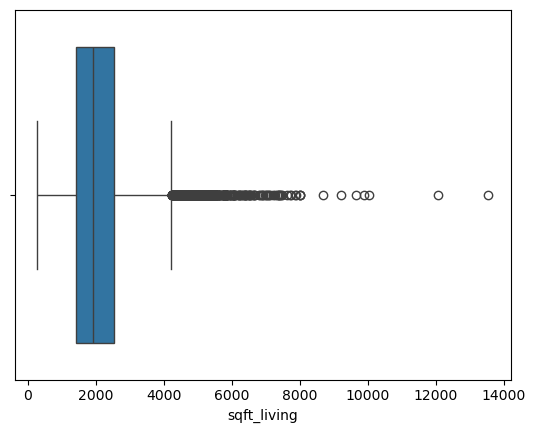

In [170]:
ax = sns.boxplot(x=df['sqft_living'])

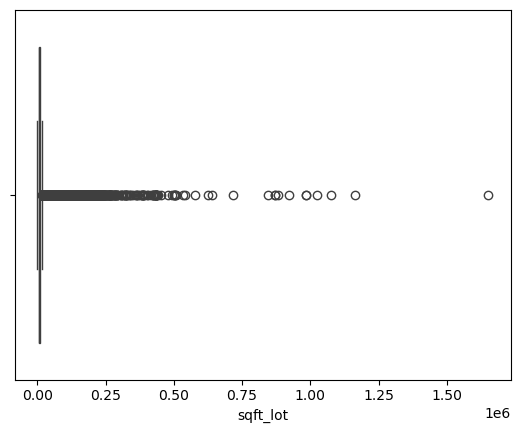

In [171]:
ax = sns.boxplot(x=df['sqft_lot'])

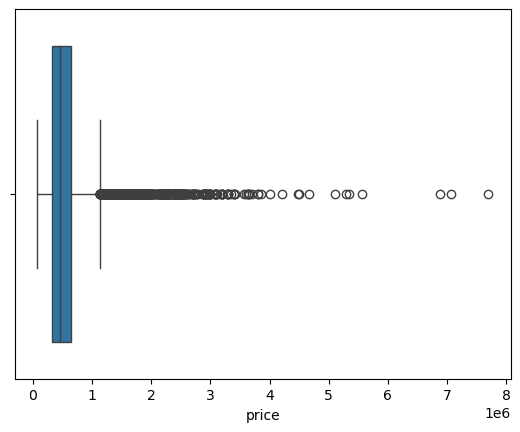

In [172]:
ax = sns.boxplot(x=df['price'])

In [173]:
df.corr(method= 'pearson',numeric_only=True)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.00,-0.02,0.00,0.01,-0.01,-0.13,0.02,-0.00,0.01,-0.02,0.01,-0.01,-0.00,0.02,-0.02,-0.01,-0.00,0.02,-0.00,-0.14
price,-0.02,1.00,0.31,0.53,0.70,0.09,0.26,0.27,0.40,0.04,0.67,0.61,0.32,0.05,0.13,-0.05,0.31,0.02,0.59,0.08
bedrooms,0.00,0.31,1.00,0.52,0.58,0.03,0.18,-0.01,0.08,0.03,0.36,0.48,0.30,0.15,0.02,-0.15,-0.01,0.13,0.39,0.03
bathrooms,0.01,0.53,0.52,1.00,0.75,0.09,0.50,0.06,0.19,-0.12,0.66,0.69,0.28,0.51,0.05,-0.20,0.02,0.22,0.57,0.09
sqft_living,-0.01,0.70,0.58,0.75,1.00,0.17,0.35,0.10,0.28,-0.06,0.76,0.88,0.43,0.32,0.06,-0.20,0.05,0.24,0.76,0.18
sqft_lot,-0.13,0.09,0.03,0.09,0.17,1.00,-0.01,0.02,0.07,-0.01,0.11,0.18,0.02,0.05,0.01,-0.13,-0.09,0.23,0.14,0.72
floors,0.02,0.26,0.18,0.50,0.35,-0.01,1.00,0.02,0.03,-0.26,0.46,0.52,-0.25,0.49,0.01,-0.06,0.05,0.13,0.28,-0.01
waterfront,-0.00,0.27,-0.01,0.06,0.10,0.02,0.02,1.00,0.40,0.02,0.08,0.07,0.08,-0.03,0.09,0.03,-0.01,-0.04,0.09,0.03
view,0.01,0.40,0.08,0.19,0.28,0.07,0.03,0.40,1.00,0.05,0.25,0.17,0.28,-0.05,0.10,0.08,0.01,-0.08,0.28,0.07
condition,-0.02,0.04,0.03,-0.12,-0.06,-0.01,-0.26,0.02,0.05,1.00,-0.14,-0.16,0.17,-0.36,-0.06,0.00,-0.01,-0.11,-0.09,-0.00


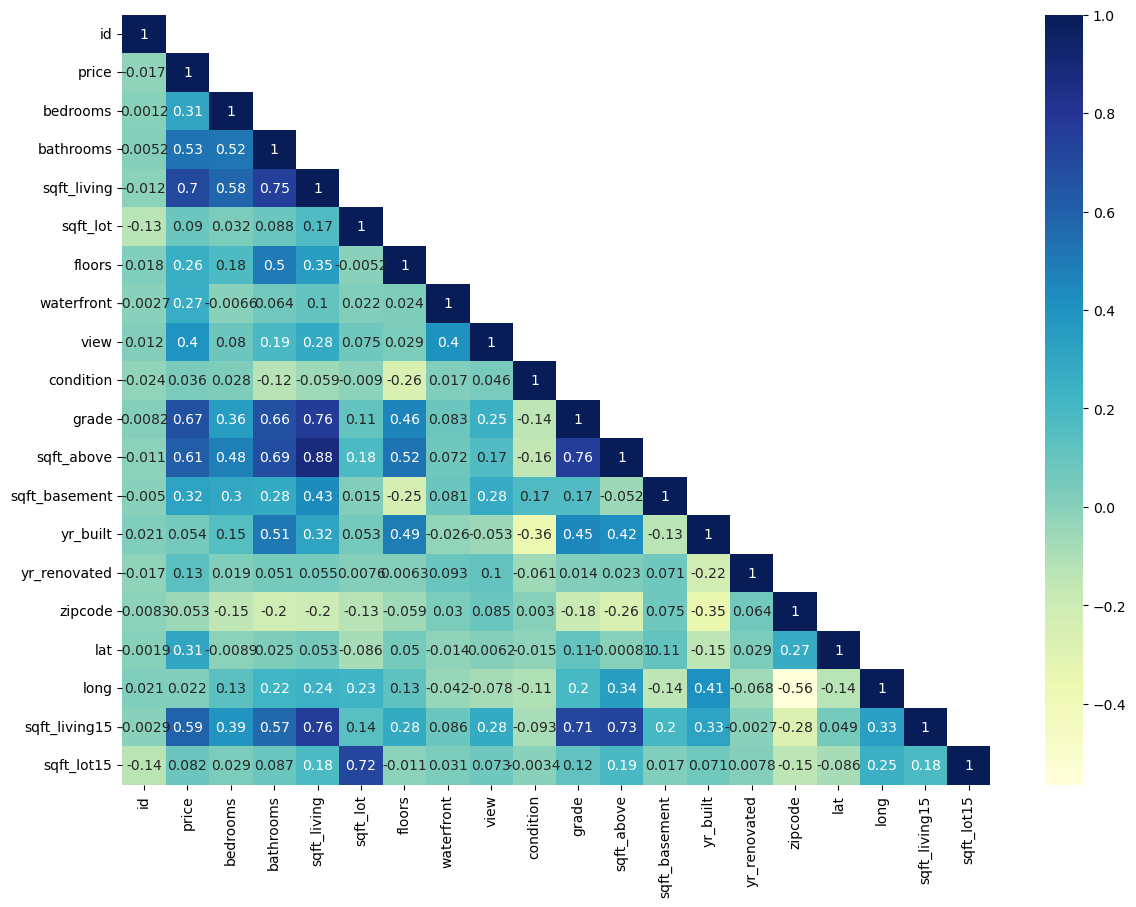

In [174]:
plt.figure(figsize=(14,10))
corr_df  = df.corr(method='pearson',numeric_only=True)
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt,cmap='YlGnBu',annot=True)

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/2977880029.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[column],ax=axes[i//4,i%4],kde=False)


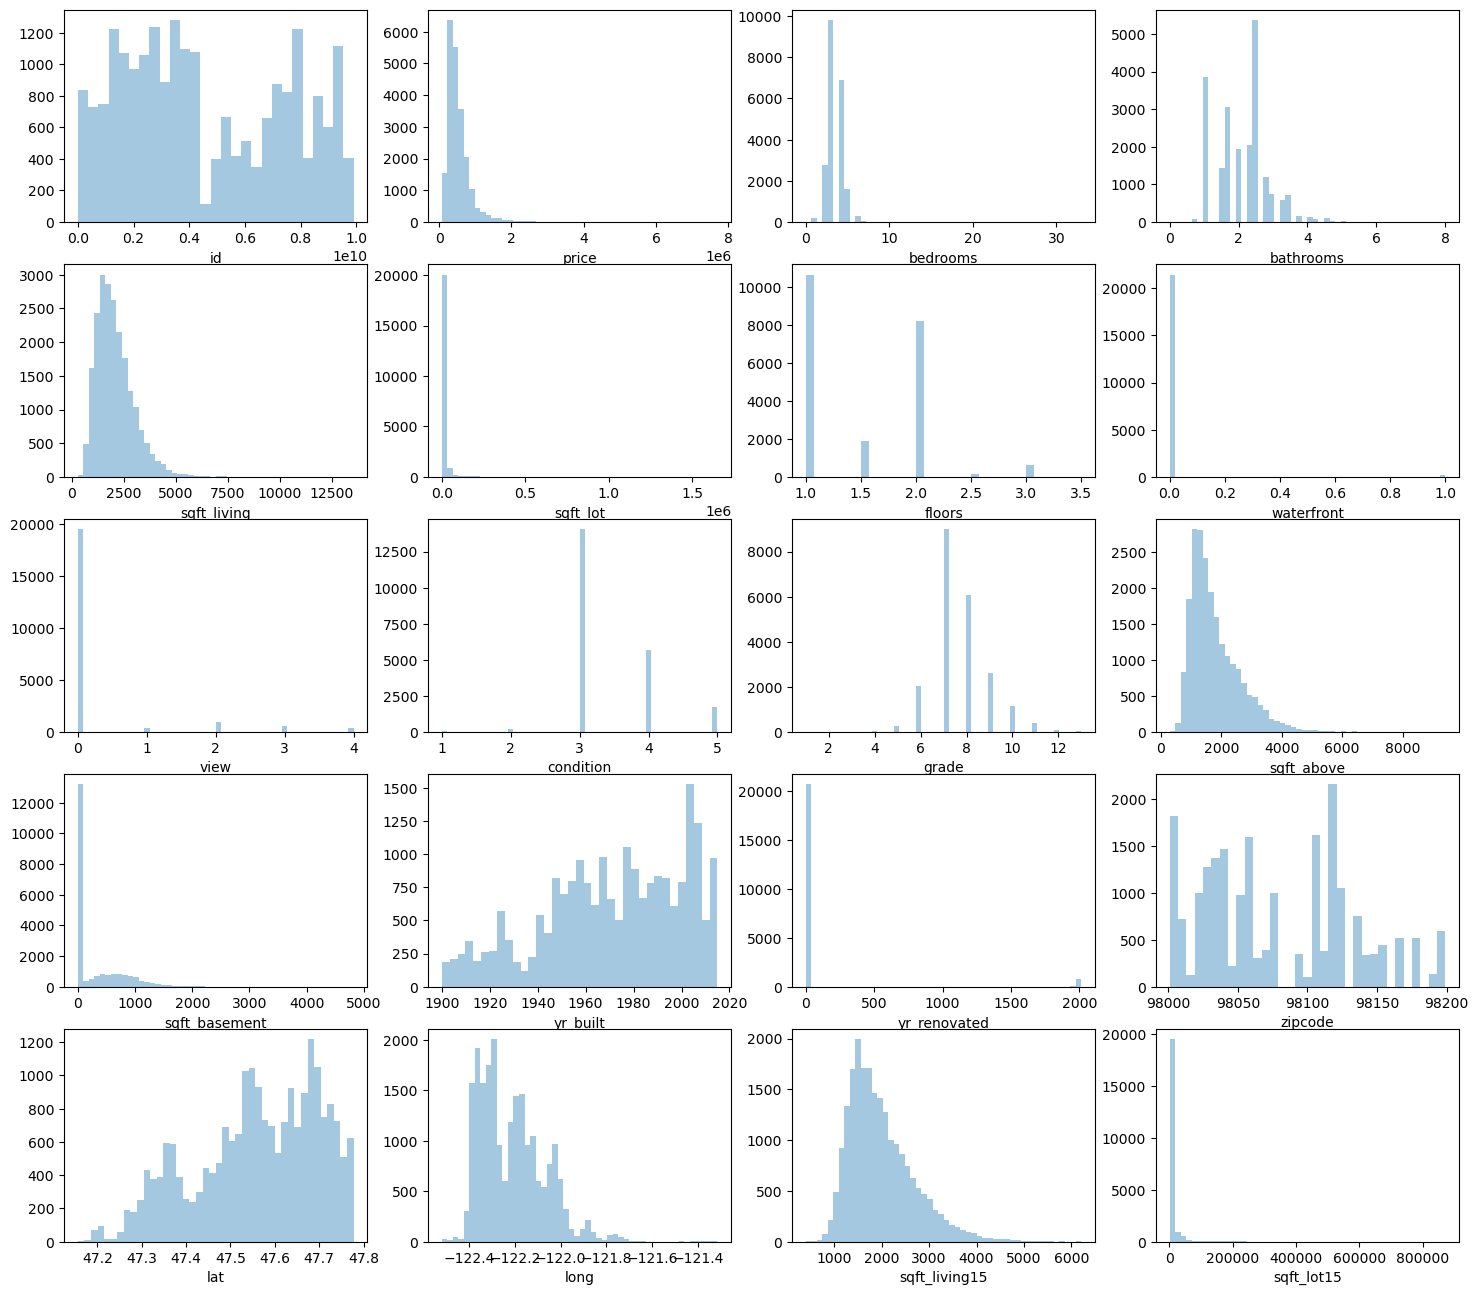

In [175]:
df_numeric = df.select_dtypes(include='number')

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(18,16))
for i, column in enumerate(df_numeric.columns):
    sns.distplot(df[column],ax=axes[i//4,i%4],kde=False)

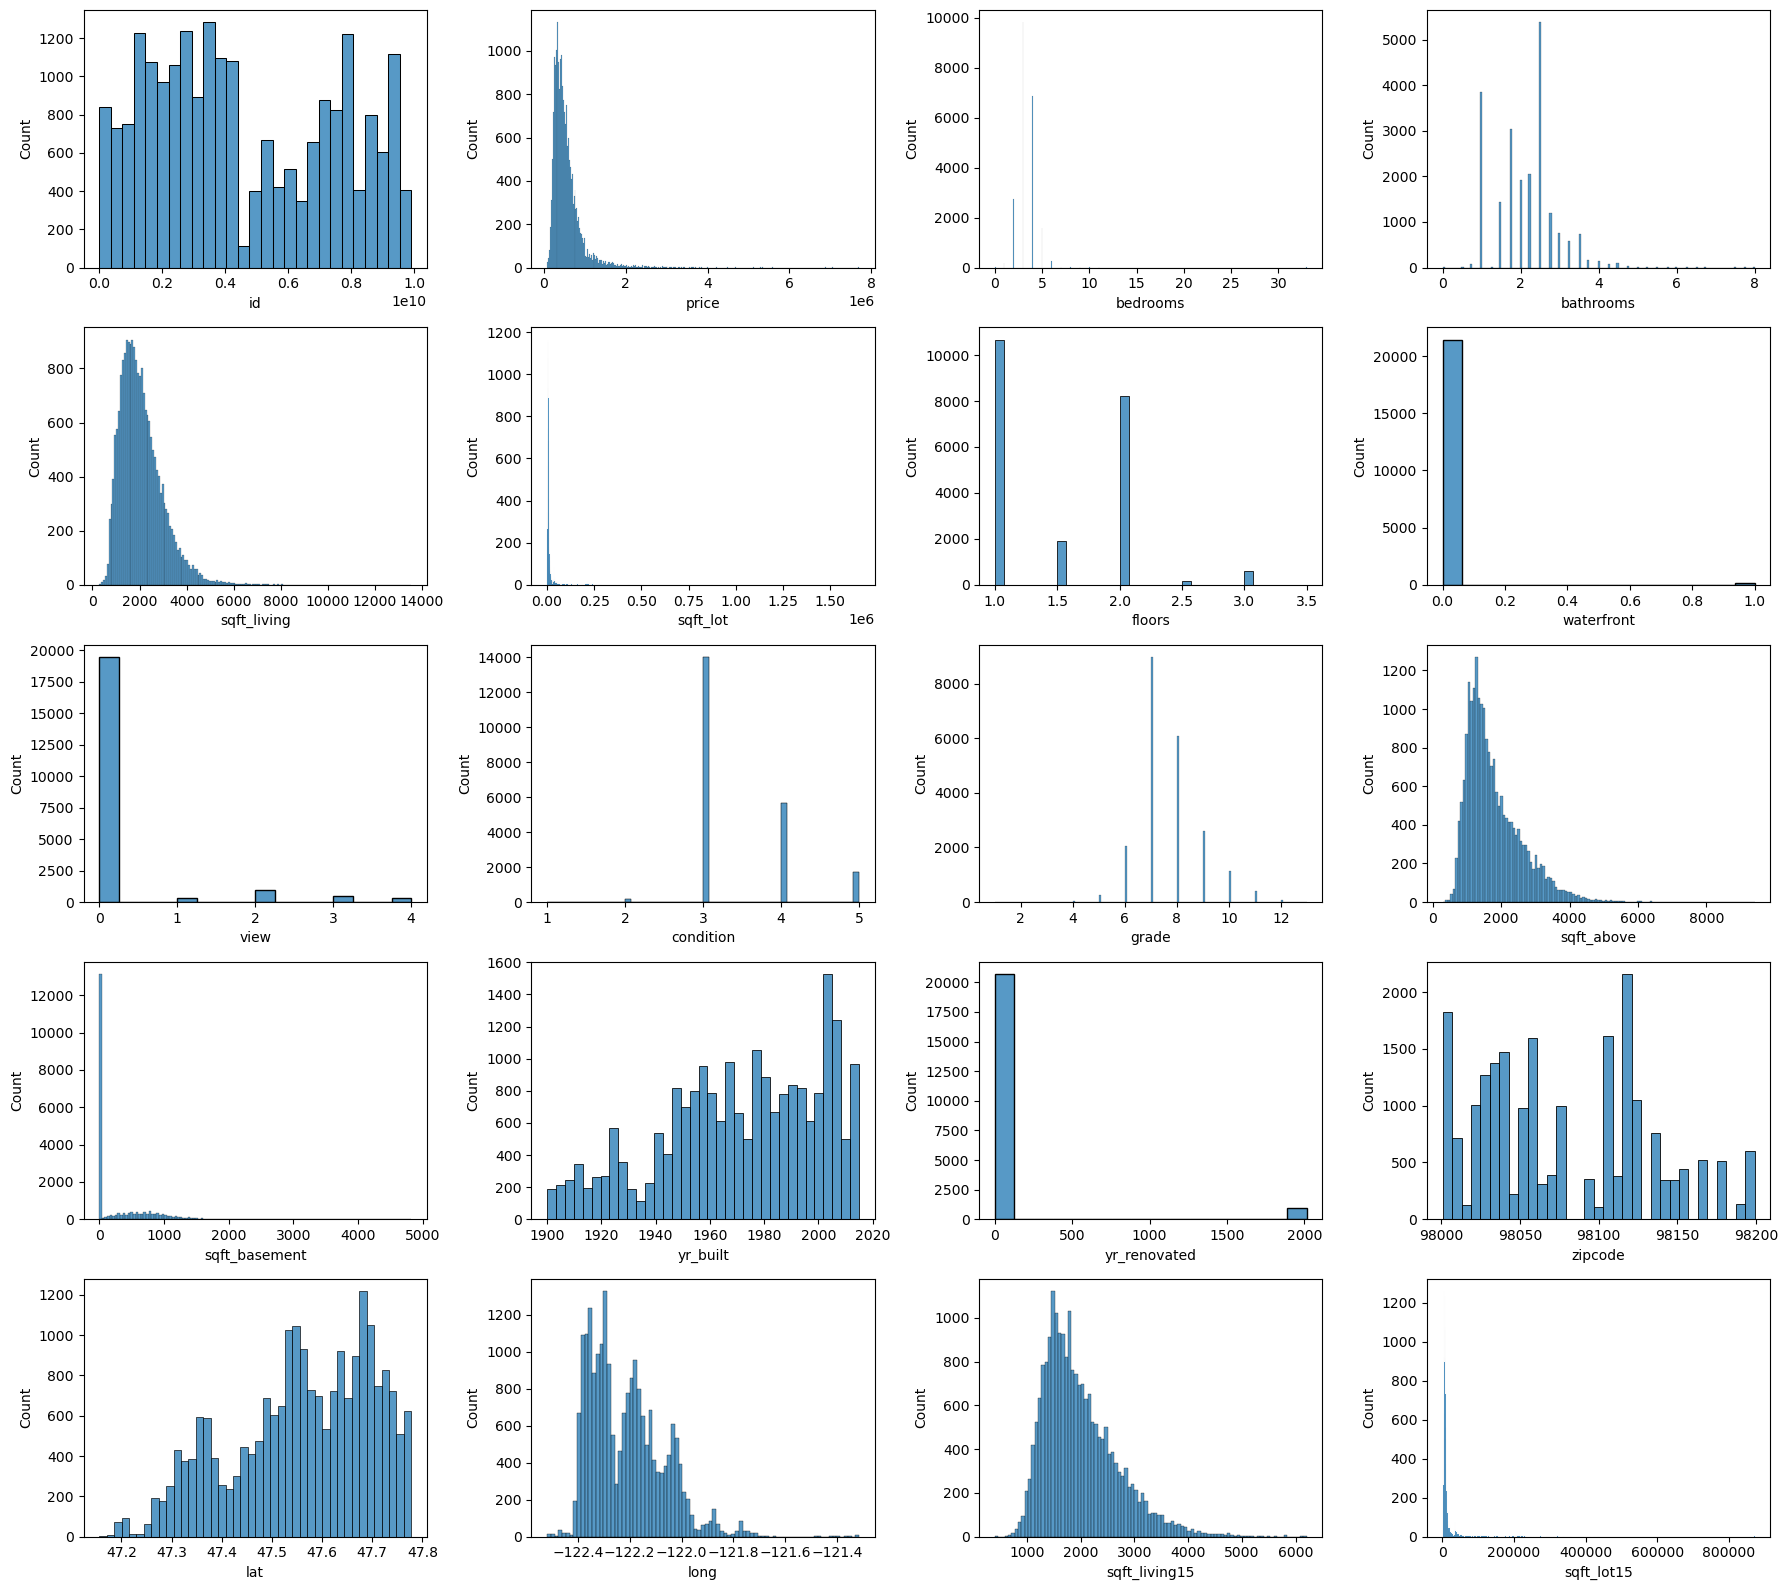

In [176]:
df_numeric = df.select_dtypes(include='number')

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(18,16))

for i, column in enumerate(df_numeric.columns):
    sns.histplot(df_numeric[column], ax=axes[i//4, i%4])

plt.tight_layout()

In [177]:
df.groupby('waterfront').median(numeric_only=True)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
waterfront,,,,,,,,,,,,,,,,,,,
0,3904935400.00,450000.00,3.00,2.25,1910.00,7588.50,1.50,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1830.00,7600.00
1,3761100045.00,1400000.00,3.00,2.50,2850.00,17342.00,2.00,4.00,3.00,9.00,2180.00,500.00,1960.00,0.00,98075.00,47.54,-122.28,2660.00,15959.00


In [178]:
df.groupby('floors').median(numeric_only=True)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
floors,,,,,,,,,,,,,,,,,,,
1.00,3885801190.00,390000.00,3.00,1.75,1630.00,8336.00,0.00,0.00,3.00,7.00,1260.00,200.00,1962.00,0.00,98070.00,47.56,-122.27,1680.00,8173.00
1.50,3856904610.00,524950.00,3.00,1.75,1760.00,5965.00,0.00,0.00,4.00,7.00,1530.00,0.00,1928.00,0.00,98115.00,47.63,-122.31,1660.00,5700.00
2.00,3982700125.00,542950.00,4.00,2.50,2440.00,7089.00,0.00,0.00,3.00,8.00,2311.00,0.00,1998.00,0.00,98055.00,47.56,-122.17,2260.00,7113.00
2.50,3751601877.00,799200.00,4.00,2.50,2850.00,5474.00,0.00,0.00,3.00,9.00,2710.00,60.00,1977.00,0.00,98106.00,47.62,-122.30,2240.00,5352.00
3.00,3448000410.00,490000.00,3.00,2.50,1500.00,1323.00,0.00,0.00,3.00,8.00,1480.00,0.00,2007.00,0.00,98109.00,47.67,-122.35,1470.00,1466.00
3.50,1972201219.00,534500.00,3.00,2.62,1730.00,1331.00,0.00,0.00,3.00,8.00,1730.00,0.00,2005.50,0.00,98104.00,47.65,-122.33,1405.00,1331.00


In [179]:
df.groupby('yr_built').median(numeric_only=True)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
yr_built,,,,,,,,,,,,,,,,,,,
1900,4232902615.00,549000.00,3.00,1.75,1540.00,5000.00,1.50,0.00,0.00,3.00,7.00,1370.00,0.00,0.00,98112.00,47.62,-122.32,1590.00,4850.00
1901,5693500760.00,550000.00,3.00,1.00,1610.00,4366.00,1.50,0.00,0.00,4.00,7.00,1390.00,0.00,0.00,98119.00,47.62,-122.31,1420.00,4000.00
1902,3359500110.00,624000.00,3.00,2.00,1600.00,4178.00,1.50,0.00,0.00,3.00,7.00,1600.00,0.00,0.00,98118.00,47.61,-122.31,1720.00,4264.00
1903,3334250867.50,461000.00,3.00,1.50,1505.00,4545.00,1.50,0.00,0.00,3.00,7.00,1330.00,0.00,0.00,98118.00,47.61,-122.31,1480.00,4553.50
1904,3362401815.00,478000.00,3.00,1.50,1280.00,4000.00,1.50,0.00,0.00,4.00,7.00,1100.00,0.00,0.00,98118.00,47.62,-122.31,1540.00,4109.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011,3326000201.00,440000.00,3.00,2.50,2270.00,4899.00,2.00,0.00,0.00,3.00,8.00,2070.00,0.00,0.00,98052.50,47.54,-122.18,2210.00,4718.00
2012,5354700281.00,448475.00,4.00,2.50,2237.50,5005.50,2.00,0.00,0.00,3.00,8.00,2170.00,0.00,0.00,98053.00,47.52,-122.16,2140.00,5000.00
2013,3448900420.00,565000.00,4.00,2.50,2580.00,5205.00,2.00,0.00,0.00,3.00,8.00,2450.00,0.00,0.00,98056.00,47.53,-122.17,2303.00,5562.00


<Axes: xlabel='floors'>

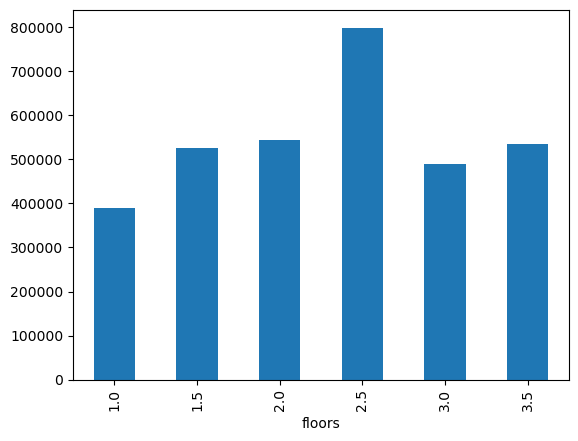

In [180]:
df.groupby('floors').median(numeric_only=True)['price'].plot.bar()

<Axes: xlabel='zipcode'>

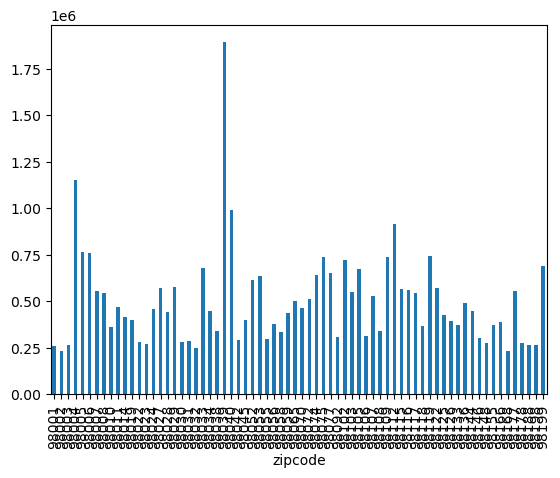

In [181]:
df.groupby('zipcode').median(numeric_only=True)['price'].plot.bar()

<Axes: xlabel='yr_built'>

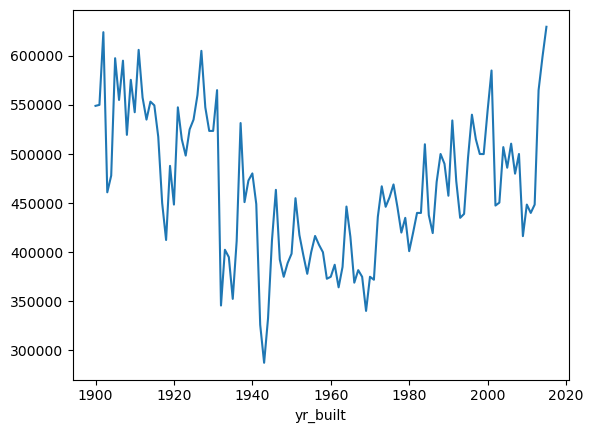

In [182]:
df.groupby('yr_built')['price'].median(numeric_only=True).plot.line()

In [183]:
df.groupby('bedrooms').median(numeric_only=True)

,id,price,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
bedrooms,,,,,,,,,,,,,,,,,,,
0,3918400017.00,288000.00,0.00,1470.00,5900.00,2.00,0.00,0.00,3.00,7.00,1470.00,0.00,1990.00,0.00,98065.00,47.53,-122.17,1810.00,7200.00
1,3340401535.00,299000.00,1.00,780.00,5750.00,1.00,0.00,0.00,3.00,6.00,760.00,0.00,1940.00,0.00,98116.00,47.56,-122.31,1360.00,5650.00
2,3904100050.00,374000.00,1.00,1140.00,5244.00,1.00,0.00,0.00,3.00,7.00,1010.00,0.00,1948.00,0.00,98116.00,47.60,-122.32,1430.00,5400.00
3,3856905010.00,413000.00,2.00,1680.00,7629.00,1.00,0.00,0.00,3.00,7.00,1440.00,0.00,1976.00,0.00,98059.00,47.56,-122.23,1720.00,7688.00
4,4029400080.00,550000.00,2.50,2410.00,8100.00,2.00,0.00,0.00,3.00,8.00,2080.00,0.00,1980.00,0.00,98056.00,47.57,-122.19,2190.00,8000.00
5,4036400040.00,620000.00,2.75,2870.00,8925.00,2.00,0.00,0.00,3.00,8.00,2190.00,700.00,1975.00,0.00,98056.00,47.58,-122.21,2280.00,8550.00
6,3876050645.00,650000.00,3.00,2955.00,8696.00,2.00,0.00,0.00,3.00,8.00,2340.00,885.00,1966.00,0.00,98097.00,47.60,-122.27,2095.00,8241.00
7,3618729798.00,728580.00,3.50,3335.00,8836.00,2.00,0.00,0.00,3.00,8.00,2820.00,750.00,1964.50,0.00,98104.00,47.62,-122.28,2215.00,8088.00
8,3756900027.00,700000.00,3.25,3840.00,7500.00,2.00,0.00,0.00,3.00,8.00,2530.00,1300.00,1962.00,0.00,98105.00,47.63,-122.30,1780.00,7624.00


In [184]:
pd.crosstab(df['waterfront'],df['floors'])

floors,1.00,1.50,2.00,2.50,3.00,3.50
waterfront,,,,,,
0,10622,1888,8166,159,605,8
1,57,21,75,2,8,0


In [185]:
pd.crosstab(df['waterfront'],df['floors'],normalize='index')

floors,1.00,1.50,2.00,2.50,3.00,3.50
waterfront,,,,,,
0,0.50,0.09,0.38,0.01,0.03,0.00
1,0.35,0.13,0.46,0.01,0.05,0.00


<Axes: xlabel='grade'>

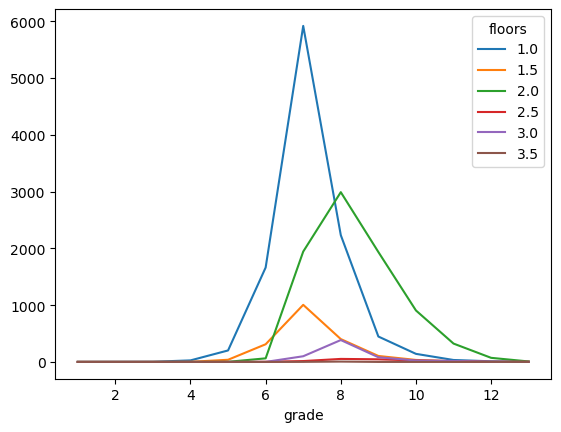

In [186]:
pd.crosstab(df['grade'],df['floors']).plot()

In [187]:
pd.crosstab(df['grade'],df['floors'],margins=True,margins_name='Total')

floors,1.00,1.50,2.00,2.50,3.00,3.50,Total
grade,,,,,,,
1,1,0,0,0,0,0,1
3,3,0,0,0,0,0,3
4,27,2,0,0,0,0,29
5,202,38,2,0,0,0,242
6,1662,311,63,2,0,0,2038
7,5916,1005,1943,15,100,1,8980
8,2232,402,2989,53,385,6,6067
9,447,105,1935,46,82,0,2615
10,142,35,906,26,25,0,1134


In [188]:
dfct1 = pd.crosstab(df['grade'],df['floors'],values=df.price,aggfunc='mean',margins=True,margins_name='Total')
dfct1 = dfct1.replace(np.nan,0)
dfct1

floors,1.00,1.50,2.00,2.50,3.00,3.50,Total
grade,,,,,,,
1,142000.00,0.00,0.00,0.00,0.00,0.00,142000.00
3,205666.67,0.00,0.00,0.00,0.00,0.00,205666.67
4,216187.04,190000.00,0.00,0.00,0.00,0.00,214381.03
5,244425.53,270364.32,247500.00,0.00,0.00,0.00,248523.97
6,294411.45,341526.30,302590.71,361250.00,0.00,0.00,301919.64
7,390574.93,503909.41,386962.93,516613.27,373947.39,1095000.00,402581.09
8,552742.22,696781.78,519103.51,643799.36,495449.12,511916.67,542833.04
9,856428.37,950667.83,740172.50,940176.52,787944.76,0.00,773513.19
10,1161105.12,1271418.57,1033278.10,1537926.92,1195030.60,0.00,1071771.07


In [189]:
dfct1.style.background_gradient(cmap='Greens').set_properties(**{'front-size':'10px'})

floors,1.000000,1.500000,2.000000,2.500000,3.000000,3.500000,Total
grade,,,,,,,
1,142000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,142000.000000
3,205666.666667,0.000000,0.000000,0.000000,0.000000,0.000000,205666.666667
4,216187.037037,190000.000000,0.000000,0.000000,0.000000,0.000000,214381.034483
5,244425.529703,270364.315789,247500.000000,0.000000,0.000000,0.000000,248523.971074
6,294411.447653,341526.302251,302590.714286,361250.000000,0.000000,0.000000,301919.637390
7,390574.927485,503909.410945,386962.933093,516613.266667,373947.390000,1095000.000000,402581.085301
8,552742.224014,696781.776119,519103.507862,643799.358491,495449.124675,511916.666667,542833.044668
9,856428.369128,950667.828571,740172.500258,940176.521739,787944.756098,0.000000,773513.185851
10,1161105.119718,1271418.571429,1033278.097130,1537926.923077,1195030.600000,0.000000,1071771.074074


In [190]:
df.sample(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
5108,7852010670,20140709T000000,692500.00,4,2.75,3710,7984,2.00,0,0,...,9,3710.00,0,1999,0,98065,47.54,-121.87,2950,7984
2097,8161600135,20140527T000000,688000.00,4,3.00,3000,4000,1.50,0,3,...,8,1970.00,1030,1913,2014,98144,47.57,-122.31,1900,4000
13729,1423049029,20150306T000000,265000.00,4,1.75,1970,8390,1.00,0,0,...,7,1140.00,830,1955,0,98178,47.49,-122.25,1710,10890
15100,7504180170,20140707T000000,410000.00,3,2.25,1450,19206,2.00,0,0,...,7,1450.00,0,1989,0,98074,47.62,-122.05,1710,21485
13348,9285800330,20140702T000000,732000.00,3,3.75,2670,6517,2.50,0,4,...,8,2020.00,650,1977,0,98126,47.57,-122.38,2010,6073


In [191]:
df.groupby('yr_built')['yr_built'].count()

yr_built
1900     87
1901     29
1902     27
1903     46
1904     45
       ... 
2011    130
2012    170
2013    201
2014    559
2015     38
Name: yr_built, Length: 116, dtype: int64

<Axes: xlabel='yr_built'>

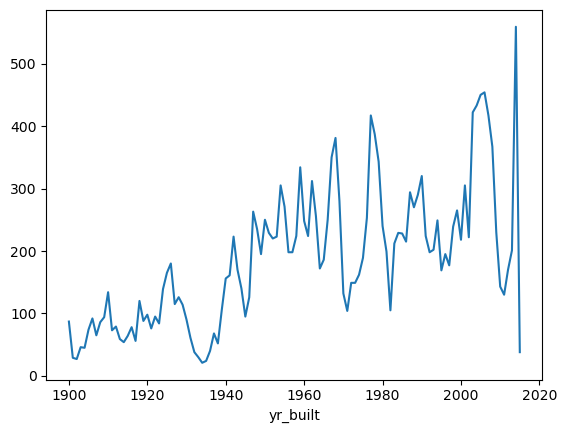

In [192]:
df.groupby('yr_built')['yr_built'].count().plot()

<Axes: xlabel='yr_built'>

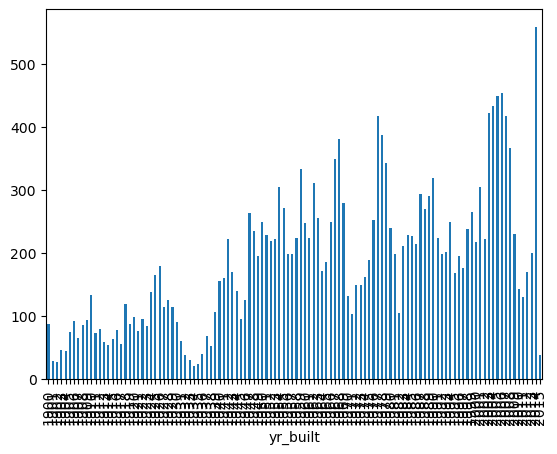

In [193]:
df.groupby('yr_built')['yr_built'].count().plot.bar()

In [194]:
df.groupby('yr_built')['price'].mean()

yr_built
1900   581387.21
1901   556935.93
1902   673007.41
1903   480958.20
1904   583756.64
          ...   
2011   544522.00
2012   527447.34
2013   678545.45
2014   683681.75
2015   759785.16
Name: price, Length: 116, dtype: float64

<Axes: xlabel='yr_built'>

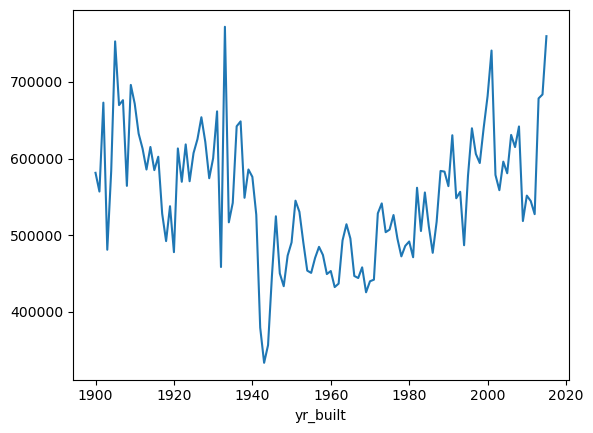

In [195]:
df.groupby('yr_built')['price'].mean().plot()

In [196]:
df.groupby('yr_built')[['floors','sqft_living','sqft_lot','price','grade']].mean()

,floors,sqft_living,sqft_lot,price,grade
yr_built,,,,,
1900,1.51,1732.01,10869.60,581387.21,6.87
1901,1.57,1763.62,4142.93,556935.93,7.03
1902,1.74,1919.63,4766.52,673007.41,7.44
1903,1.46,1507.74,6364.57,480958.20,6.87
1904,1.34,1603.18,5410.00,583756.64,6.91
...,...,...,...,...,...
2011,2.02,2313.68,6519.69,544522.00,8.18
2012,1.99,2378.74,6085.54,527447.34,8.18
2013,2.04,2636.59,7338.08,678545.45,8.47


<Axes: xlabel='yr_built'>

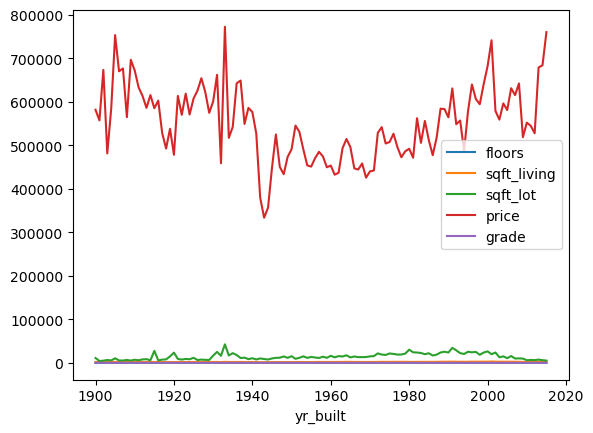

In [197]:
df.groupby('yr_built')[['floors','sqft_living','sqft_lot','price','grade']].mean().plot()

In [198]:
df.groupby('zipcode')['price'].mean()

zipcode
98001    280804.69
98002    234284.04
98003    294111.28
98004   1355927.08
98005    810164.88
           ...    
98177    676185.39
98178    310612.76
98188    289078.35
98198    302878.88
98199    791820.81
Name: price, Length: 70, dtype: float64

In [199]:
df.groupby('zipcode')['price'].mean().sort_values(ascending=False)

zipcode
98039   2160606.60
98004   1355927.08
98040   1194230.02
98112   1095499.34
98102    901258.27
           ...    
98148    284908.60
98001    280804.69
98032    251296.24
98168    240328.37
98002    234284.04
Name: price, Length: 70, dtype: float64

In [200]:
df.groupby('zipcode')['price'].mean().sort_values(ascending=False).head(10)

zipcode
98039   2160606.60
98004   1355927.08
98040   1194230.02
98112   1095499.34
98102    901258.27
98109    879623.62
98105    862825.23
98006    859684.78
98119    849448.02
98005    810164.88
Name: price, dtype: float64

<Axes: ylabel='zipcode'>

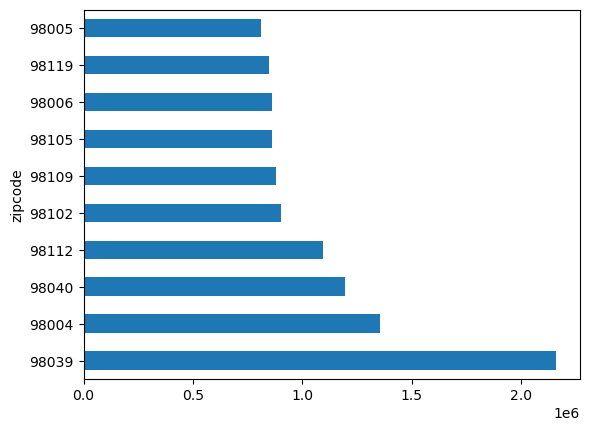

In [201]:
df.groupby('zipcode')['price'].mean().sort_values(ascending=False).head(10).plot.barh()

<Axes: ylabel='zipcode'>

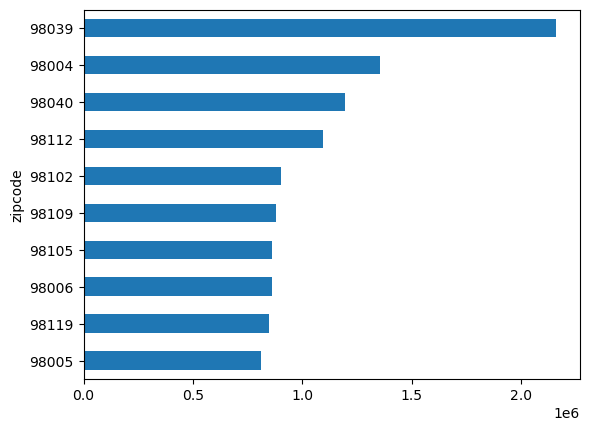

In [202]:
df.groupby('zipcode')['price'].mean().sort_values(ascending=False).head(10).iloc[::-1].plot.barh()

In [203]:
pd.options.display.float_format='{:.2f}'.format

In [204]:
df2 = df.groupby(['zipcode','waterfront'])['price'].mean().sort_values(ascending=False).head(50)

In [205]:
df2.head()

zipcode  waterfront
98004    1            7062500.00
98039    1            3640900.00
98033    1            3444950.00
98105    1            3051666.67
98040    1            2960416.67
Name: price, dtype: float64

In [206]:
df2.unstack().head(10)

waterfront,0,1
zipcode,,
98004,1337868.31,7062500.00
98039,2130396.53,3640900.00
98033,779035.13,3444950.00
98105,833769.81,3051666.67
98040,1115732.84,2960416.67
98144,NaN,2750000.00
98008,NaN,2571666.67
98034,NaN,2481666.67
98027,NaN,2400000.00


In [207]:
df3 = df.groupby(['zipcode','floors'])['price'].mean().sort_values(ascending=False).head(100)
df3

zipcode  floors
98112    3.50     3300000.00
98008    2.50     2789000.00
98039    2.00     2659193.93
98033    2.50     2350000.00
98053    3.00     2280000.00
                     ...    
98177    3.00      686100.00
         1.50      685910.71
98116    2.00      682997.87
98075    1.00      681536.94
98199    1.00      680911.12
Name: price, Length: 100, dtype: float64

In [208]:
df3.unstack().head(10)

floors,1.00,1.50,2.00,2.50,3.00,3.50
zipcode,,,,,,
98112,827606.58,911528.88,1190472.75,1648095.24,908078.46,3300000.00
98008,NaN,763571.43,925086.67,2789000.00,NaN,NaN
98039,1526040.91,NaN,2659193.93,NaN,NaN,NaN
98033,NaN,707906.25,979655.62,2350000.00,NaN,NaN
98053,NaN,710625.00,732626.21,958333.33,2280000.00,NaN
98040,968852.84,1272253.57,1419608.39,1061880.00,2252666.67,NaN
98144,NaN,NaN,NaN,1846000.00,NaN,NaN
98102,NaN,758210.83,862671.86,1826312.00,739375.00,1095000.00
98004,1125796.78,1537089.29,1700077.57,NaN,781700.00,NaN


<Axes: xlabel='zipcode'>

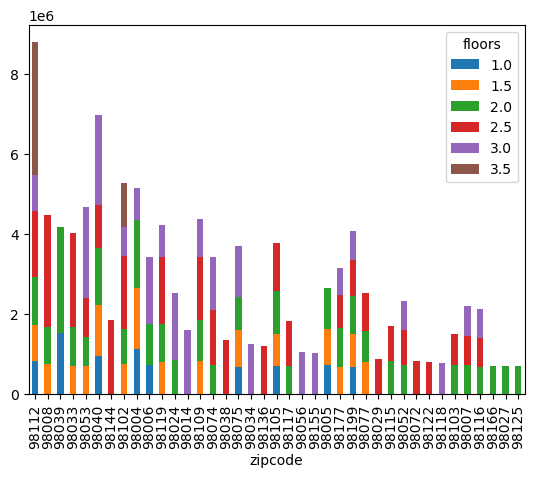

In [209]:
df3.unstack().plot.bar(stacked=True)

In [210]:
df4=df.groupby(['yr_built','zipcode'])['price'].mean().sort_values(ascending=False).head(100)
df4

yr_built  zipcode
1940      98004     7062500.00
2004      98155     4500000.00
2001      98039     4204500.00
2008      98039     4000000.00
2000      98039     3710000.00
                       ...    
1908      98004     1749000.00
2015      98112     1749000.00
1937      98112     1738000.00
2013      98040     1724950.00
1959      98039     1712750.00
Name: price, Length: 100, dtype: float64

In [211]:
df5 = df4.unstack()
df5.head()

zipcode,98004,98155,98039,98008,98034,98040,98107,98109,98177,98006,...,98053,98052,98199,98102,98116,98125,98074,98105,98005,98115
yr_built,,,,,,,,,,,,,,,,,,,,,
1940,7062500.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004,2312233.33,4500000.00,2187730.00,NaN,NaN,2298000.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001,2381250.00,NaN,4204500.00,2989000.00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008,1756589.21,NaN,4000000.00,NaN,NaN,2090000.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000,NaN,NaN,3710000.00,NaN,NaN,1831666.67,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [212]:
df5 = df5.replace(np.nan,0)

In [213]:
df6 = df.groupby(['yr_built','zipcode','waterfront'])['price'].mean().sort_values(ascending=False).head(100)
df6

yr_built  zipcode  waterfront
1940      98004    1            7062500.00
1991      98040    1            5300000.00
1983      98040    1            4668000.00
2004      98155    1            4500000.00
2001      98039    0            4204500.00
                                   ...    
1938      98105    0            1920000.00
2007      98004    0            1914545.45
1955      98112    0            1910000.00
1992      98004    0            1901000.00
1996      98005    0            1900000.00
Name: price, Length: 100, dtype: float64

In [214]:
type(df6)

pandas.core.series.Series

In [215]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

df1 = pd.read_csv('sales_January_2019.csv')
df2 = pd.read_csv('sales_February_2019.csv')
df3 = pd.read_csv('sales_March_2019.csv')
df4 = pd.read_csv('sales_April_2019.csv')
df5 = pd.read_csv('sales_May_2019.csv')
df6 = pd.read_csv('sales_June_2019.csv')
df7 = pd.read_csv('sales_July_2019.csv')
df8 = pd.read_csv('sales_August_2019.csv')
df9 = pd.read_csv('sales_September_2019.csv')
df10 = pd.read_csv('sales_October_2019.csv')
df11 = pd.read_csv('sales_November_2019.csv')
df12 = pd.read_csv('sales_December_2019.csv')

df = df1
df['Month'] = '2019-01-01'

In [216]:
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",2019-01-01
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",2019-01-01
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",2019-01-01
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",2019-01-01
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",2019-01-01
...,...,...,...,...,...,...,...
9718,150497,20in Monitor,1,109.99,01/26/19 19:09,"95 8th St, Dallas, TX 75001",2019-01-01
9719,150498,27in FHD Monitor,1,149.99,01/10/19 22:58,"403 7th St, San Francisco, CA 94016",2019-01-01
9720,150499,ThinkPad Laptop,1,999.99,01/21/19 14:31,"214 Main St, Portland, OR 97035",2019-01-01
9721,150500,AAA Batteries (4-pack),2,2.99,01/15/19 14:21,"810 2nd St, Los Angeles, CA 90001",2019-01-01


In [217]:
df = pd.concat([df, df2])
df['Month'] = df['Month'].fillna('2019-02-01')
df = pd.concat([df, df3])
df['Month'] = df['Month'].fillna('2019-03-01')
df = pd.concat([df, df4])
df['Month'] = df['Month'].fillna('2019-04-01')
df = pd.concat([df, df5])
df['Month'] = df['Month'].fillna('2019-05-01')
df = pd.concat([df, df6])
df['Month'] = df['Month'].fillna('2019-06-01')
df = pd.concat([df, df7])
df['Month'] = df['Month'].fillna('2019-07-01')
df = pd.concat([df, df8])
df['Month'] = df['Month'].fillna('2019-08-01')
df = pd.concat([df, df9])
df['Month'] = df['Month'].fillna('2019-09-01')
df = pd.concat([df, df10])
df['Month'] = df['Month'].fillna('2019-10-01')
df = pd.concat([df, df11])
df['Month'] = df['Month'].fillna('2019-11-01')
df = pd.concat([df, df12])
df['Month'] = df['Month'].fillna('2019-12-01')

In [218]:
df.sample(10)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
4024,180414,USB-C Charging Cable,1,11.95,04/02/19 16:54,"720 5th St, New York City, NY 10001",2019-04-01
908,194953,AA Batteries (4-pack),2,3.84,05/16/19 17:30,"424 Ridge St, Los Angeles, CA 90001",2019-05-01
7046,216631,27in 4K Gaming Monitor,1,389.99,06/08/19 14:28,"93 Ridge St, Los Angeles, CA 90001",2019-06-01
6357,265424,27in 4K Gaming Monitor,1,389.99,10/10/19 11:01,"166 Willow St, Austin, TX 73301",2019-10-01
1001,249114,USB-C Charging Cable,1,11.95,09/22/19 20:22,"794 Lakeview St, Atlanta, GA 30301",2019-09-01
16920,311836,AAA Batteries (4-pack),1,2.99,12/05/19 15:09,"647 Lake St, Boston, MA 02215",2019-12-01
13907,236230,Wired Headphones,3,11.99,07/06/19 13:05,"920 Church St, San Francisco, CA 94016",2019-07-01
494,279271,Lightning Charging Cable,1,14.95,11/28/19 21:44,"327 11th St, Los Angeles, CA 90001",2019-11-01
3193,165044,Google Phone,1,600,03/24/19 08:25,"471 Park St, New York City, NY 10001",2019-03-01
7809,286266,Flatscreen TV,1,300,11/24/19 14:19,"518 Wilson St, San Francisco, CA 94016",2019-11-01


In [219]:
df.groupby('Month')['Month'].count()

Month
2019-01-01     9723
2019-02-01    12036
2019-03-01    15226
2019-04-01    18383
2019-05-01    16635
2019-06-01    13622
2019-07-01    14371
2019-08-01    12011
2019-09-01    11686
2019-10-01    20379
2019-11-01    17661
2019-12-01    25117
Name: Month, dtype: int64

<Axes: xlabel='Month'>

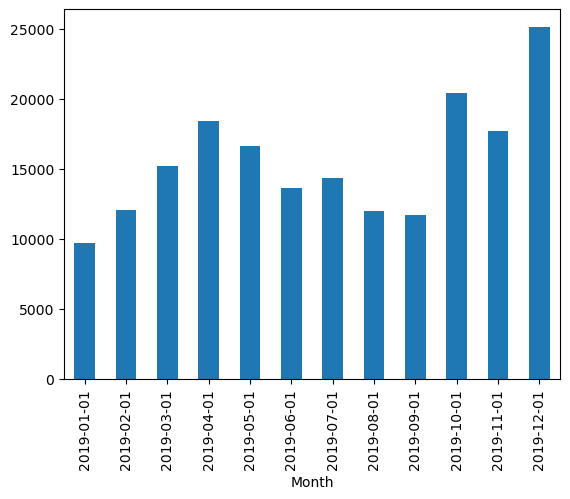

In [220]:
df.groupby('Month')['Month'].count().plot.bar()

In [221]:
df.shape

(186850, 7)

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186850 entries, 0 to 25116
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
 6   Month             186850 non-null  object
dtypes: object(7)
memory usage: 11.4+ MB


In [223]:
df.sample(10)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
2859,281538,Macbook Pro Laptop,1,1700,11/08/19 00:19,"285 Johnson St, Seattle, WA 98101",2019-11-01
15080,273752,Macbook Pro Laptop,1,1700,10/13/19 20:04,"690 8th St, New York City, NY 10001",2019-10-01
7489,169162,20in Monitor,1,109.99,03/18/19 10:54,"692 13th St, Portland, OR 97035",2019-03-01
8729,202387,Apple Airpods Headphones,1,150,05/15/19 21:22,"405 Hill St, New York City, NY 10001",2019-05-01
600,210496,ThinkPad Laptop,1,999.99,06/13/19 00:30,"438 Dogwood St, Seattle, WA 98101",2019-06-01
12178,221542,34in Ultrawide Monitor,1,379.99,06/21/19 15:23,"707 Meadow St, Boston, MA 02215",2019-06-01
12389,188373,USB-C Charging Cable,2,11.95,04/24/19 21:49,"198 Washington St, San Francisco, CA 94016",2019-04-01
15169,310153,27in 4K Gaming Monitor,1,389.99,12/06/19 21:08,"35 7th St, Boston, MA 02215",2019-12-01
4894,166673,Lightning Charging Cable,1,14.95,03/19/19 19:15,"274 2nd St, Los Angeles, CA 90001",2019-03-01
8583,287001,AA Batteries (4-pack),1,3.84,11/24/19 17:45,"442 Ridge St, Austin, TX 73301",2019-11-01


In [224]:
df = df.dropna(how='all')
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",2019-01-01
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",2019-01-01
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",2019-01-01
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",2019-01-01
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",2019-01-01
...,...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,12/11/19 20:58,"14 Madison St, San Francisco, CA 94016",2019-12-01
25113,319667,AA Batteries (4-pack),2,3.84,12/01/19 12:01,"549 Willow St, Los Angeles, CA 90001",2019-12-01
25114,319668,Vareebadd Phone,1,400,12/09/19 06:43,"273 Wilson St, Seattle, WA 98101",2019-12-01
25115,319669,Wired Headphones,1,11.99,12/03/19 10:39,"778 River St, Dallas, TX 75001",2019-12-01


In [225]:
df['Order Date']

0        01/22/19 21:25
1        01/28/19 14:15
2        01/17/19 13:33
3        01/05/19 20:33
4        01/25/19 11:59
              ...      
25112    12/11/19 20:58
25113    12/01/19 12:01
25114    12/09/19 06:43
25115    12/03/19 10:39
25116    12/21/19 21:45
Name: Order Date, Length: 186850, dtype: object

In [226]:
df = df[df['Order Date'].str[0:2]!='Or']
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",2019-01-01
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",2019-01-01
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",2019-01-01
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",2019-01-01
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",2019-01-01
...,...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,12/11/19 20:58,"14 Madison St, San Francisco, CA 94016",2019-12-01
25113,319667,AA Batteries (4-pack),2,3.84,12/01/19 12:01,"549 Willow St, Los Angeles, CA 90001",2019-12-01
25114,319668,Vareebadd Phone,1,400,12/09/19 06:43,"273 Wilson St, Seattle, WA 98101",2019-12-01
25115,319669,Wired Headphones,1,11.99,12/03/19 10:39,"778 River St, Dallas, TX 75001",2019-12-01


In [227]:
df['Month'] = pd.to_datetime(df['Month'])
df['Order Date'] = pd.to_datetime(df['Order Date'])

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/1129690287.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = pd.to_datetime(df['Month'])
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/1129690287.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/1129690287.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

In [228]:
df['Quantity Ordered'].unique()

array(['1', '2', '3', '5', '4', nan, '7', '6', '9', '8'], dtype=object)

In [229]:
df['Order ID'] = df['Order ID'].astype('string')
df['Product'] = df['Product'].astype('string')
df['Quantity Ordered'] = df['Quantity Ordered'].fillna(0)
df['Quantity Ordered'] = df['Quantity Ordered'].astype('int64')
df['Price Each'] = df['Price Each'].astype('float')
df['Purchase Address'] = df['Purchase Address'].astype('string')

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/1465858101.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order ID'] = df['Order ID'].astype('string')
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/1465858101.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Product'] = df['Product'].astype('string')
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/1465858101.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [230]:
print(df.dtypes)

Order ID            string[python]
Product             string[python]
Quantity Ordered             int64
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address    string[python]
Month               datetime64[ns]
dtype: object


In [231]:
missing_values_count = df.isnull().sum()
missing_values_count[:10]

Order ID            545
Product             545
Quantity Ordered      0
Price Each          545
Order Date          545
Purchase Address    545
Month                 0
dtype: int64

In [232]:
total_cells = np.prod(df.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells)*100
print(f'Porcentaje de datos que no existen: {percent_missing:.2f}%')

Porcentaje de datos que no existen: 0.21%


In [233]:
df[df['Quantity Ordered'] == 0]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
664,<NA>,<NA>,0,NaN,NaT,<NA>,2019-01-01
678,<NA>,<NA>,0,NaN,NaT,<NA>,2019-01-01
797,<NA>,<NA>,0,NaN,NaT,<NA>,2019-01-01
876,<NA>,<NA>,0,NaN,NaT,<NA>,2019-01-01
1299,<NA>,<NA>,0,NaN,NaT,<NA>,2019-01-01
...,...,...,...,...,...,...,...
22945,<NA>,<NA>,0,NaN,NaT,<NA>,2019-12-01
22962,<NA>,<NA>,0,NaN,NaT,<NA>,2019-12-01
23309,<NA>,<NA>,0,NaN,NaT,<NA>,2019-12-01
23996,<NA>,<NA>,0,NaN,NaT,<NA>,2019-12-01


In [234]:
df[df['Quantity Ordered'] > 0]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,141234,iPhone,1,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",2019-01-01
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",2019-01-01
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",2019-01-01
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",2019-01-01
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",2019-01-01
...,...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,2019-12-11 20:58:00,"14 Madison St, San Francisco, CA 94016",2019-12-01
25113,319667,AA Batteries (4-pack),2,3.84,2019-12-01 12:01:00,"549 Willow St, Los Angeles, CA 90001",2019-12-01
25114,319668,Vareebadd Phone,1,400.00,2019-12-09 06:43:00,"273 Wilson St, Seattle, WA 98101",2019-12-01
25115,319669,Wired Headphones,1,11.99,2019-12-03 10:39:00,"778 River St, Dallas, TX 75001",2019-12-01


In [235]:
missing_values_count = df.isnull().sum()
missing_values_count[:10]

Order ID            545
Product             545
Quantity Ordered      0
Price Each          545
Order Date          545
Purchase Address    545
Month                 0
dtype: int64

In [236]:
df.shape

(186495, 7)

In [237]:
df = df.dropna()


In [238]:
missing_values_count = df.isnull().sum()
missing_values_count[:10]

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
dtype: int64

In [239]:
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,Quantity Ordered,Price Each,Order Date,Month
count,185950.00,185950.00,185950,185950
mean,1.12,184.40,2019-07-18 21:54:38.887550208,2019-07-03 11:51:07.056735488
min,1.00,2.99,2019-01-01 03:07:00,2019-01-01 00:00:00
25%,1.00,11.95,2019-04-16 21:05:15,2019-04-01 00:00:00
50%,1.00,14.95,2019-07-17 20:40:30,2019-07-01 00:00:00
75%,1.00,150.00,2019-10-26 08:14:00,2019-10-01 00:00:00
max,9.00,1700.00,2020-01-01 05:13:00,2019-12-01 00:00:00
std,0.44,332.73,NaN,NaN


In [240]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity Ordered,185950.00,1.12,1.00,1.00,1.00,1.00,9.00,0.44
Price Each,185950.00,184.40,2.99,11.95,14.95,150.00,1700.00,332.73
Order Date,185950,2019-07-18 21:54:38.887550208,2019-01-01 03:07:00,2019-04-16 21:05:15,2019-07-17 20:40:30,2019-10-26 08:14:00,2020-01-01 05:13:00,NaN
Month,185950,2019-07-03 11:51:07.056735488,2019-01-01 00:00:00,2019-04-01 00:00:00,2019-07-01 00:00:00,2019-10-01 00:00:00,2019-12-01 00:00:00,NaN


In [241]:
df.shape[0]

185950

In [242]:
df['Purchase Address']

0               944 Walnut St, Boston, MA 02215
1              185 Maple St, Portland, OR 97035
2         538 Adams St, San Francisco, CA 94016
3            738 10th St, Los Angeles, CA 90001
4                 387 10th St, Austin, TX 73301
                          ...                  
25112    14 Madison St, San Francisco, CA 94016
25113      549 Willow St, Los Angeles, CA 90001
25114          273 Wilson St, Seattle, WA 98101
25115            778 River St, Dallas, TX 75001
25116    747 Chestnut St, Los Angeles, CA 90001
Name: Purchase Address, Length: 185950, dtype: string

In [243]:
df['zipcode'] = df['Purchase Address'].str[-6:]

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/5260927.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['zipcode'] = df['Purchase Address'].str[-6:]


In [244]:
df['zipcode'].unique()

<StringArray>
[' 02215', ' 97035', ' 94016', ' 90001', ' 73301', ' 30301', ' 98101',
 ' 10001', ' 75001', ' 04101']
Length: 10, dtype: string

In [245]:
df['zipcode'] = df['zipcode'].astype('string')

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/590836886.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['zipcode'] = df['zipcode'].astype('string')


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185950 entries, 0 to 25116
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185950 non-null  string        
 1   Product           185950 non-null  string        
 2   Quantity Ordered  185950 non-null  int64         
 3   Price Each        185950 non-null  float64       
 4   Order Date        185950 non-null  datetime64[ns]
 5   Purchase Address  185950 non-null  string        
 6   Month             185950 non-null  datetime64[ns]
 7   zipcode           185950 non-null  string        
dtypes: datetime64[ns](2), float64(1), int64(1), string(4)
memory usage: 12.8 MB


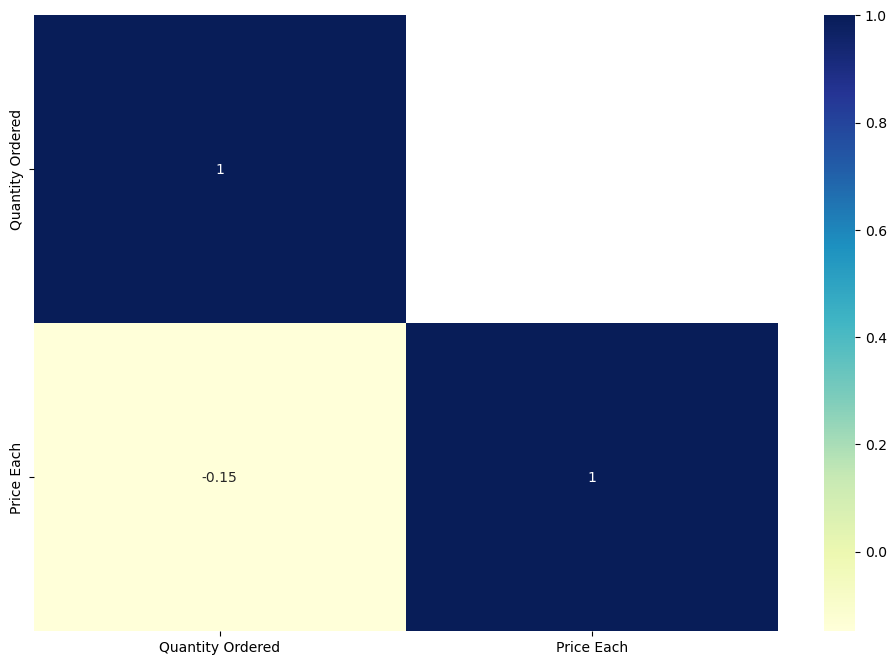

In [247]:
plt.figure(figsize=(12,8))
corr_df = corr = df.corr(method='pearson',numeric_only=True)
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype('bool'))
hmap = sns.heatmap(df_lt,cmap='YlGnBu',annot=True)

In [248]:
print('List of Columns')
print('-----------------------------')
print(df.columns)
print(len(df.columns),' columns')

cols_num = ['Quantity ordered', 'Price Each' ]

List of Columns
-----------------------------
Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address', 'Month', 'zipcode'],
      dtype='object')
8  columns


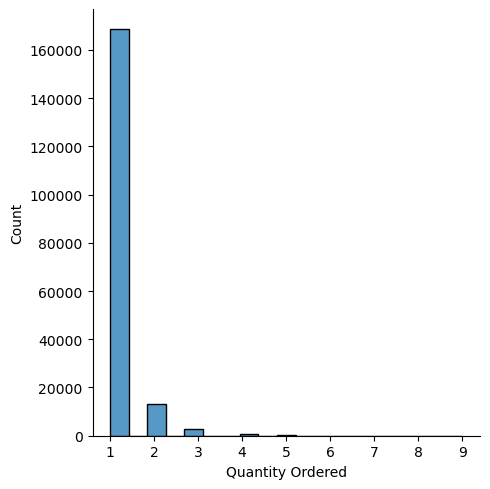

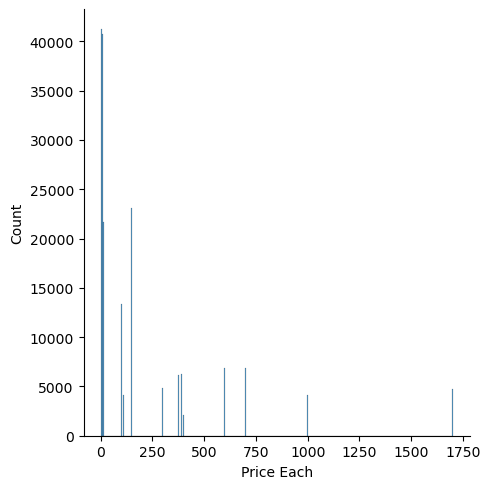

In [249]:
sns.displot(df['Quantity Ordered'], kde=False)
sns.displot(df['Price Each'], kde = False)

In [250]:
df.groupby('Month').mean(numeric_only=True)

,Quantity Ordered,Price Each
Month,,
2019-01-01,1.12,186.45
2019-02-01,1.12,182.74
2019-03-01,1.12,184.32
2019-04-01,1.12,184.43
2019-05-01,1.13,188.90
2019-06-01,1.13,189.03
2019-07-01,1.12,184.15
2019-08-01,1.12,186.53
2019-09-01,1.13,179.40


In [251]:
df.groupby('Product').median(numeric_only=True)

,Quantity Ordered,Price Each
Product,,
20in Monitor,1.00,109.99
27in 4K Gaming Monitor,1.00,389.99
27in FHD Monitor,1.00,149.99
34in Ultrawide Monitor,1.00,379.99
AA Batteries (4-pack),1.00,3.84
AAA Batteries (4-pack),1.00,2.99
Apple Airpods Headphones,1.00,150.00
Bose SoundSport Headphones,1.00,99.99
Flatscreen TV,1.00,300.00


<Axes: xlabel='Product'>

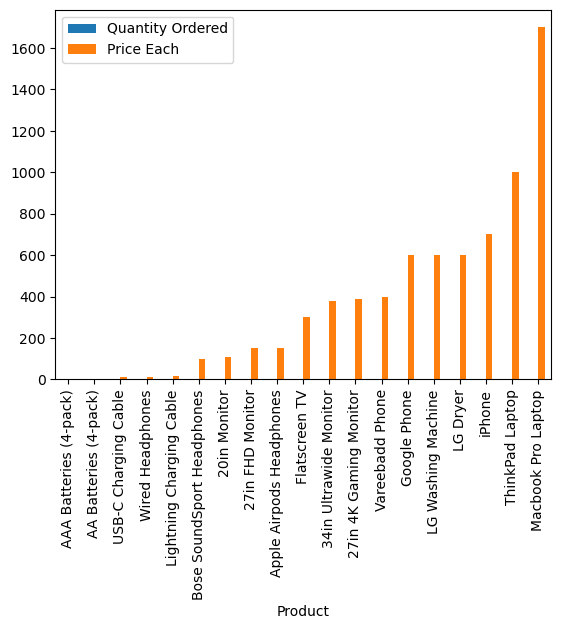

In [252]:
df.groupby('Product').median(numeric_only=True).sort_values(by='Price Each').plot.bar()

In [253]:
df['ProductGroup'] = ''

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/1288272204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ProductGroup'] = ''


In [254]:
len(df['Product'].unique())

19

In [255]:
df.loc[(df['Product']=='20in Monitor'),'ProductGroup']='Monitor'
df.loc[(df['Product']=='iPhone'),'ProductGroup']='Phone'
df.loc[(df['Product']=='Wired Headphones'),'ProductGroup']='Headphones'
df.loc[(df['Product']=='AAA Batteries (4-pack)'),'ProductGroup']='Batteries'
df.loc[(df['Product']=='USB-C Charging Cable'),'ProductGroup']='Cable'
df.loc[(df['Product']=='Apple Airpods Headphones'),'ProductGroup']='Headphones'
df.loc[(df['Product']=='Flatscreen TV'),'ProductGroup']='Monitor'
df.loc[(df['Product']=='AA Batteries (4-pack)'),'ProductGroup']='Batteries'
df.loc[(df['Product']=='ThinkPad Laptop'),'ProductGroup']='Laptop'
df.loc[(df['Product']=='LG Washing Machine'),'ProductGroup']='Other'
df.loc[(df['Product']=='Lightning Charging Cable'),'ProductGroup']='Cable'
df.loc[(df['Product']=='27in FHD Monitor'),'ProductGroup']='Monitor'
df.loc[(df['Product']=='27in 4K Gaming Monitor'),'ProductGroup']='Monitor'
df.loc[(df['Product']=='Bose SoundSport Headphones'),'ProductGroup']='Headphones'
df.loc[(df['Product']=='Macbook Pro Laptop'),'ProductGroup']='Laptop'
df.loc[(df['Product']=='Vareebadd Phone'),'ProductGroup']='Phone'
df.loc[(df['Product']=='Google Phone'),'ProductGroup']='Phone'
df.loc[(df['Product']=='34in Ultrawide Monitor'),'ProductGroup']='Monitor'
df.loc[(df['Product']=='LG Dryer'),'ProductGroup']='Other'

In [256]:
df.groupby('ProductGroup').median(numeric_only=True)

,Quantity Ordered,Price Each
ProductGroup,,
Batteries,1.00,2.99
Cable,1.00,11.95
Headphones,1.00,99.99
Laptop,1.00,1700.00
Monitor,1.00,300.00
Other,1.00,600.00
Phone,1.00,600.00


In [257]:
df.groupby('zipcode').mean(numeric_only=True)

,Quantity Ordered,Price Each
zipcode,,
02215,1.13,182.47
04101,1.12,182.15
10001,1.12,186.34
30301,1.12,186.81
73301,1.13,182.72
75001,1.13,185.74
90001,1.12,183.13
94016,1.12,183.57
97035,1.13,185.87


In [258]:
df.groupby(['ProductGroup','zipcode']).mean(numeric_only=True)

Quantity Ordered  Price Each
ProductGroup zipcode                              
Batteries    02215                1.43        3.41
             04101                1.41        3.46
             10001                1.42        3.41
             30301                1.40        3.42
             73301                1.43        3.41
...                                ...         ...
Phone        75001                1.00      614.08
             90001                1.00      621.19
             94016                1.00      619.21
             97035                1.00      620.66
             98101                1.00      616.15

[70 rows x 2 columns]

In [259]:
pd.crosstab(df['zipcode'],df['Month'])

Month,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,2019-11-01,2019-12-01
zipcode,,,,,,,,,,,,
02215,1048,1256,1648,1918,1800,1392,1552,1245,1283,2176,1918,2698
04101,123,177,188,243,222,197,199,165,145,251,230,315
10001,1303,1611,1981,2434,2268,1776,1930,1626,1536,2648,2355,3408
30301,786,936,1245,1472,1331,1104,1146,941,915,1605,1412,1988
73301,527,626,840,973,839,715,762,649,666,1090,868,1350
75001,785,981,1202,1350,1420,1066,1098,968,935,1639,1371,2005
90001,1529,1901,2456,3026,2568,2201,2235,1867,1884,3294,2750,3894
94016,2354,2912,3597,4437,3921,3304,3530,2833,2734,4767,4322,6021
97035,500,659,795,994,944,745,720,657,594,1135,934,1333


<Axes: xlabel='Month'>

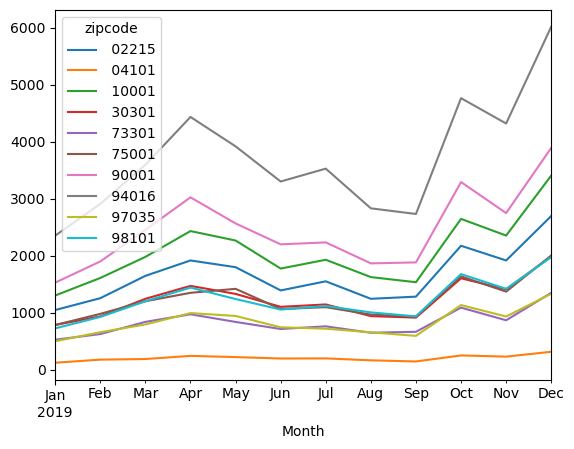

In [260]:
pd.crosstab(df['Month'],df['zipcode']).plot()

In [261]:
df['Total Sales'] = df['Quantity Ordered'] * df['Price Each']

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/3550351240.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total Sales'] = df['Quantity Ordered'] * df['Price Each']


In [262]:
df.sample(5)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,zipcode,ProductGroup,Total Sales
11114,204653,iPhone,1,700.00,2019-05-18 14:45:00,"415 2nd St, San Francisco, CA 94016",2019-05-01,94016,Phone,700.00
24447,319024,Lightning Charging Cable,1,14.95,2019-12-25 11:06:00,"224 Pine St, Austin, TX 73301",2019-12-01,73301,Cable,14.95
16031,209357,27in 4K Gaming Monitor,1,389.99,2019-05-06 19:19:00,"172 Pine St, New York City, NY 10001",2019-05-01,10001,Monitor,389.99
11603,173087,Lightning Charging Cable,1,14.95,2019-03-06 21:05:00,"275 Jackson St, Los Angeles, CA 90001",2019-03-01,90001,Cable,14.95
9761,219222,27in 4K Gaming Monitor,1,389.99,2019-06-23 21:12:00,"454 Lake St, Los Angeles, CA 90001",2019-06-01,90001,Monitor,389.99


In [263]:
pd.crosstab(df['Product'],df['Month'],values=df['Total Sales'],aggfunc='sum',margins=True)

Month,2019-01-01 00:00:00,2019-02-01 00:00:00,2019-03-01 00:00:00,2019-04-01 00:00:00,2019-05-01 00:00:00,2019-06-01 00:00:00,2019-07-01 00:00:00,2019-08-01 00:00:00,2019-09-01 00:00:00,2019-10-01 00:00:00,2019-11-01 00:00:00,2019-12-01 00:00:00,All
Product,,,,,,,,,,,,,
20in Monitor,23647.85,27057.54,35856.74,43446.05,37396.60,35306.79,35966.73,28817.38,30467.23,47075.72,46305.79,62804.29,454148.71
27in 4K Gaming Monitor,121676.88,166915.72,186805.21,220344.35,211374.58,176275.48,188365.17,171205.61,148976.18,281962.77,225414.22,335781.39,2435097.56
27in FHD Monitor,62845.81,71245.25,91343.91,110542.63,103193.12,85194.32,90743.95,73795.08,72295.18,118792.08,107692.82,144740.35,1132424.50
34in Ultrawide Monitor,119316.86,158835.82,199114.76,248133.47,206714.56,172515.46,175555.38,144776.19,143636.22,255353.28,208994.50,322611.51,2355558.01
AA Batteries (4-pack),5472.00,6666.24,8509.44,10836.48,9150.72,8044.80,7956.48,7011.84,6808.32,11285.76,10099.20,14277.12,106118.40
AAA Batteries (4-pack),4772.04,5905.25,7409.22,8778.64,8763.69,6458.40,7074.34,6036.81,5761.73,10052.38,9050.73,12677.60,92740.83
Apple Airpods Headphones,122100.00,151950.00,198150.00,228750.00,203850.00,175050.00,183150.00,151500.00,145200.00,251100.00,226500.00,311850.00,2349150.00
Bose SoundSport Headphones,65893.41,84391.56,119688.03,128787.12,117388.26,98390.16,105989.40,87991.20,82991.70,146485.35,125087.49,182481.75,1345565.43
Flatscreen TV,72900.00,94200.00,108600.00,137700.00,119700.00,110100.00,119700.00,99300.00,88200.00,157500.00,138300.00,199500.00,1445700.00


In [264]:
pd.crosstab(df['ProductGroup'],df['Month'],values=df['Total Sales'],aggfunc='sum',margins=True)

Month,2019-01-01 00:00:00,2019-02-01 00:00:00,2019-03-01 00:00:00,2019-04-01 00:00:00,2019-05-01 00:00:00,2019-06-01 00:00:00,2019-07-01 00:00:00,2019-08-01 00:00:00,2019-09-01 00:00:00,2019-10-01 00:00:00,2019-11-01 00:00:00,2019-12-01 00:00:00,All
ProductGroup,,,,,,,,,,,,,
Batteries,10244.04,12571.49,15918.66,19615.12,17914.41,14503.20,15030.82,13048.65,12570.05,21338.14,19149.93,26954.72,198859.23
Cable,32551.25,42145.45,51262.05,62572.95,55775.70,45263.80,49161.05,39013.85,40471.65,70316.05,60031.60,85030.00,633595.40
Headphones,200954.60,251712.74,337765.41,382308.46,343719.51,291137.40,307879.77,254958.30,243802.68,424850.61,374824.11,527280.27,3941193.86
Laptop,616497.83,744497.23,989996.56,1165496.08,1155096.32,920196.85,943596.82,783297.25,738597.51,1352495.40,1121996.26,1635794.59,12167558.70
Monitor,400387.40,518254.33,621720.62,760166.50,678378.86,579392.05,610331.23,517894.26,483574.81,860683.85,726707.33,1065437.54,7822928.78
Other,48600.00,46800.00,68400.00,82800.00,84000.00,58800.00,64200.00,56400.00,45600.00,66600.00,65400.00,99600.00,787200.00
Phone,506100.00,587500.00,724000.00,923100.00,809700.00,669000.00,656700.00,579800.00,534200.00,940600.00,830800.00,1179200.00,8940700.00
All,1815335.12,2203481.24,2809063.30,3396059.11,3144584.80,2578293.30,2646899.69,2244412.31,2098816.70,3736884.05,3198909.23,4619297.12,34492035.97


In [265]:
df[df['Month']=='2019-01-01']['Total Sales'].sum()

np.float64(1815335.1199999999)

In [266]:
df[(df['Month']=='2019-01-01') & (df['Product']=='20in Monitor')]['Total Sales'].sum()

np.float64(23647.85)

In [267]:
df_sales= pd.pivot_table(df,values='Total Sales',index='Month',columns='Product',aggfunc='sum').fillna(0).reset_index()
df_sales

Product,Month,20in Monitor,27in 4K Gaming Monitor,27in FHD Monitor,34in Ultrawide Monitor,AA Batteries (4-pack),AAA Batteries (4-pack),Apple Airpods Headphones,Bose SoundSport Headphones,Flatscreen TV,Google Phone,LG Dryer,LG Washing Machine,Lightning Charging Cable,Macbook Pro Laptop,ThinkPad Laptop,USB-C Charging Cable,Vareebadd Phone,Wired Headphones,iPhone
0,2019-01-01,23647.85,121676.88,62845.81,119316.86,5472.00,4772.04,122100.00,65893.41,72900.00,190800.00,23400.00,25200.00,17207.45,399500.00,216997.83,15343.80,50000.00,12961.19,265300.00
1,2019-02-01,27057.54,166915.72,71245.25,158835.82,6666.24,5905.25,151950.00,84391.56,94200.00,228600.00,22800.00,24000.00,22380.15,467500.00,276997.23,19765.30,51600.00,15371.18,307300.00
2,2019-03-01,35856.74,186805.21,91343.91,199114.76,8509.44,7409.22,198150.00,119688.03,108600.00,277800.00,30000.00,38400.00,28031.25,646000.00,343996.56,23230.80,69600.00,19927.38,376600.00
3,2019-04-01,43446.05,220344.35,110542.63,248133.47,10836.48,8778.64,228750.00,128787.12,137700.00,348600.00,46200.00,36600.00,35446.45,773500.00,391996.08,27126.50,88000.00,24771.34,486500.00
4,2019-05-01,37396.60,211374.58,103193.12,206714.56,9150.72,8763.69,203850.00,117388.26,119700.00,288000.00,45600.00,38400.00,31051.15,787100.00,367996.32,24724.55,74400.00,22481.25,447300.00
5,2019-06-01,35306.79,176275.48,85194.32,172515.46,8044.80,6458.40,175050.00,98390.16,110100.00,234600.00,25800.00,33000.00,25235.60,605200.00,314996.85,20028.20,62000.00,17697.24,372400.00
6,2019-07-01,35966.73,188365.17,90743.95,175555.38,7956.48,7074.34,183150.00,105989.40,119700.00,246600.00,33000.00,31200.00,27089.40,625600.00,317996.82,22071.65,58000.00,18740.37,352100.00
7,2019-08-01,28817.38,171205.61,73795.08,144776.19,7011.84,6036.81,151500.00,87991.20,99300.00,216000.00,27600.00,28800.00,21542.95,508300.00,274997.25,17470.90,57200.00,15467.10,306600.00
8,2019-09-01,30467.23,148976.18,72295.18,143636.22,6808.32,5761.73,145200.00,82991.70,88200.00,205200.00,18000.00,27600.00,21423.35,489600.00,248997.51,19048.30,50400.00,15610.98,278600.00
9,2019-10-01,47075.72,281962.77,118792.08,255353.28,11285.76,10052.38,251100.00,146485.35,157500.00,358200.00,30000.00,36600.00,38421.50,892500.00,459995.40,31894.55,81200.00,27265.26,501200.00


In [268]:
pd.pivot_table(df,values='Total Sales',index='Month',columns='ProductGroup',aggfunc='sum').fillna(0).reset_index()

ProductGroup,Month,Batteries,Cable,Headphones,Laptop,Monitor,Other,Phone
0,2019-01-01,10244.04,32551.25,200954.60,616497.83,400387.40,48600.00,506100.00
1,2019-02-01,12571.49,42145.45,251712.74,744497.23,518254.33,46800.00,587500.00
2,2019-03-01,15918.66,51262.05,337765.41,989996.56,621720.62,68400.00,724000.00
3,2019-04-01,19615.12,62572.95,382308.46,1165496.08,760166.50,82800.00,923100.00
4,2019-05-01,17914.41,55775.70,343719.51,1155096.32,678378.86,84000.00,809700.00
5,2019-06-01,14503.20,45263.80,291137.40,920196.85,579392.05,58800.00,669000.00
6,2019-07-01,15030.82,49161.05,307879.77,943596.82,610331.23,64200.00,656700.00
7,2019-08-01,13048.65,39013.85,254958.30,783297.25,517894.26,56400.00,579800.00
8,2019-09-01,12570.05,40471.65,243802.68,738597.51,483574.81,45600.00,534200.00
9,2019-10-01,21338.14,70316.05,424850.61,1352495.40,860683.85,66600.00,940600.00


In [269]:
df_sales[list(df_sales.columns[1:20])].pct_change()

Product,20in Monitor,27in 4K Gaming Monitor,27in FHD Monitor,34in Ultrawide Monitor,AA Batteries (4-pack),AAA Batteries (4-pack),Apple Airpods Headphones,Bose SoundSport Headphones,Flatscreen TV,Google Phone,LG Dryer,LG Washing Machine,Lightning Charging Cable,Macbook Pro Laptop,ThinkPad Laptop,USB-C Charging Cable,Vareebadd Phone,Wired Headphones,iPhone
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.14,0.37,0.13,0.33,0.22,0.24,0.24,0.28,0.29,0.20,-0.03,-0.05,0.30,0.17,0.28,0.29,0.03,0.19,0.16
2,0.33,0.12,0.28,0.25,0.28,0.25,0.30,0.42,0.15,0.22,0.32,0.60,0.25,0.38,0.24,0.18,0.35,0.30,0.23
3,0.21,0.18,0.21,0.25,0.27,0.18,0.15,0.08,0.27,0.25,0.54,-0.05,0.26,0.20,0.14,0.17,0.26,0.24,0.29
4,-0.14,-0.04,-0.07,-0.17,-0.16,-0.00,-0.11,-0.09,-0.13,-0.17,-0.01,0.05,-0.12,0.02,-0.06,-0.09,-0.15,-0.09,-0.08
5,-0.06,-0.17,-0.17,-0.17,-0.12,-0.26,-0.14,-0.16,-0.08,-0.19,-0.43,-0.14,-0.19,-0.23,-0.14,-0.19,-0.17,-0.21,-0.17
6,0.02,0.07,0.07,0.02,-0.01,0.10,0.05,0.08,0.09,0.05,0.28,-0.05,0.07,0.03,0.01,0.10,-0.06,0.06,-0.05
7,-0.20,-0.09,-0.19,-0.18,-0.12,-0.15,-0.17,-0.17,-0.17,-0.12,-0.16,-0.08,-0.20,-0.19,-0.14,-0.21,-0.01,-0.17,-0.13
8,0.06,-0.13,-0.02,-0.01,-0.03,-0.05,-0.04,-0.06,-0.11,-0.05,-0.35,-0.04,-0.01,-0.04,-0.09,0.09,-0.12,0.01,-0.09
9,0.55,0.89,0.64,0.78,0.66,0.74,0.73,0.77,0.79,0.75,0.67,0.33,0.79,0.82,0.85,0.67,0.61,0.75,0.80


In [270]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Month                       12 non-null     datetime64[ns]
 1   20in Monitor                12 non-null     float64       
 2   27in 4K Gaming Monitor      12 non-null     float64       
 3   27in FHD Monitor            12 non-null     float64       
 4   34in Ultrawide Monitor      12 non-null     float64       
 5   AA Batteries (4-pack)       12 non-null     float64       
 6   AAA Batteries (4-pack)      12 non-null     float64       
 7   Apple Airpods Headphones    12 non-null     float64       
 8   Bose SoundSport Headphones  12 non-null     float64       
 9   Flatscreen TV               12 non-null     float64       
 10  Google Phone                12 non-null     float64       
 11  LG Dryer                    12 non-null     float64       
 

In [271]:
dfsalespct = df_sales[list(df_sales.columns[1:20])].pct_change()

In [272]:
dfsalespct.mean().sort_values(ascending=False)

Product
27in 4K Gaming Monitor       0.14
LG Dryer                     0.13
34in Ultrawide Monitor       0.13
Macbook Pro Laptop           0.13
Bose SoundSport Headphones   0.13
Lightning Charging Cable     0.13
Flatscreen TV                0.13
AAA Batteries (4-pack)       0.12
ThinkPad Laptop              0.12
Wired Headphones             0.12
AA Batteries (4-pack)        0.12
USB-C Charging Cable         0.12
Apple Airpods Headphones     0.12
20in Monitor                 0.11
iPhone                       0.11
Vareebadd Phone              0.11
Google Phone                 0.11
27in FHD Monitor             0.10
LG Washing Machine           0.09
dtype: float64

In [274]:
pd.pivot_table(df,values='Total Sales',index='Month',columns='zipcode',aggfunc='sum').fillna(0).reset_index()

zipcode,Month,02215,04101,10001,30301,73301,75001,90001,94016,97035,98101
0,2019-01-01,199776.55,22708.80,259250.67,149163.38,87587.08,143465.50,287613.86,433103.45,92123.77,140542.06
1,2019-02-01,215796.39,29845.49,305396.20,176566.45,108790.39,184950.05,342161.69,548644.98,119999.35,171330.25
2,2019-03-01,301063.55,30516.29,370198.22,231811.37,154546.28,222976.68,429982.33,692157.31,156298.74,219512.53
3,2019-04-01,353880.16,42536.49,446587.78,284454.92,172683.59,252840.47,551399.07,817074.77,198591.62,276010.24
4,2019-05-01,327687.88,57978.76,436418.35,239262.96,160745.21,266379.49,499696.90,772319.75,172591.21,211504.29
5,2019-06-01,254859.87,30025.33,323874.60,219395.51,143971.20,188897.70,450254.15,613607.51,139553.91,213853.52
6,2019-07-01,291535.16,33021.14,355623.79,211766.47,150301.03,210310.23,394851.52,642985.78,143990.65,212513.92
7,2019-08-01,240275.25,35396.60,303157.81,169267.66,125713.61,179763.46,345461.66,538753.13,116893.09,189730.04
8,2019-09-01,247368.73,28759.56,301290.77,171278.89,106610.59,164215.85,354218.42,464529.65,104189.92,156354.32
9,2019-10-01,367328.34,52322.52,486401.39,306642.99,203072.22,323732.61,612445.57,865824.13,201850.29,317263.99


In [275]:
sales_zipcode = pd.pivot_table(df,values='Total Sales',index='Month',columns='zipcode',aggfunc='sum').fillna(0).reset_index()

In [276]:
sales_zipcodepct = sales_zipcode[list(sales_zipcode.columns)[1:11]].pct_change()

In [277]:
sales_zipcodepct.style.background_gradient(cmap='Blues')

zipcode,02215,04101,10001,30301,73301,75001,90001,94016,97035,98101
0,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,0.080189,0.314270,0.177996,0.183712,0.242083,0.289160,0.189656,0.266776,0.302588,0.219067
2,0.395128,0.022476,0.212190,0.312885,0.420588,0.205605,0.256664,0.261576,0.302497,0.281225
3,0.175433,0.393895,0.206348,0.227096,0.117358,0.133932,0.282376,0.180476,0.270590,0.257378
4,-0.074015,0.363036,-0.022771,-0.158872,-0.069134,0.053548,-0.093765,-0.054775,-0.130924,-0.233709
5,-0.222248,-0.482132,-0.257880,-0.083036,-0.104352,-0.290870,-0.098945,-0.205501,-0.191419,0.011107
6,0.143904,0.099776,0.098029,-0.034773,0.043966,0.113355,-0.123047,0.047878,0.031792,-0.006264
7,-0.175828,0.071938,-0.147532,-0.200687,-0.163588,-0.145246,-0.125085,-0.162107,-0.188190,-0.107211
8,0.029522,-0.187505,-0.006159,0.011882,-0.151957,-0.086489,0.025348,-0.137769,-0.108673,-0.175912
9,0.484942,0.819309,0.614392,0.790314,0.904803,0.971385,0.729005,0.863873,0.937330,1.029135


In [278]:
sales_zipcodepct

zipcode,02215,04101,10001,30301,73301,75001,90001,94016,97035,98101
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.08,0.31,0.18,0.18,0.24,0.29,0.19,0.27,0.30,0.22
2,0.40,0.02,0.21,0.31,0.42,0.21,0.26,0.26,0.30,0.28
3,0.18,0.39,0.21,0.23,0.12,0.13,0.28,0.18,0.27,0.26
4,-0.07,0.36,-0.02,-0.16,-0.07,0.05,-0.09,-0.05,-0.13,-0.23
5,-0.22,-0.48,-0.26,-0.08,-0.10,-0.29,-0.10,-0.21,-0.19,0.01
6,0.14,0.10,0.10,-0.03,0.04,0.11,-0.12,0.05,0.03,-0.01
7,-0.18,0.07,-0.15,-0.20,-0.16,-0.15,-0.13,-0.16,-0.19,-0.11
8,0.03,-0.19,-0.01,0.01,-0.15,-0.09,0.03,-0.14,-0.11,-0.18
9,0.48,0.82,0.61,0.79,0.90,0.97,0.73,0.86,0.94,1.03


In [280]:
sales_zipcodepct.mean().sort_values(ascending=False)

zipcode
98101   0.15
04101   0.14
75001   0.14
97035   0.14
73301   0.13
94016   0.13
10001   0.12
30301   0.11
02215   0.11
90001   0.11
dtype: float64

In [283]:
pd.pivot_table(df,values='Total Sales',index='Month',columns='ProductGroup',aggfunc='sum').fillna(0).reset_index()

ProductGroup,Month,Batteries,Cable,Headphones,Laptop,Monitor,Other,Phone
0,2019-01-01,10244.04,32551.25,200954.60,616497.83,400387.40,48600.00,506100.00
1,2019-02-01,12571.49,42145.45,251712.74,744497.23,518254.33,46800.00,587500.00
2,2019-03-01,15918.66,51262.05,337765.41,989996.56,621720.62,68400.00,724000.00
3,2019-04-01,19615.12,62572.95,382308.46,1165496.08,760166.50,82800.00,923100.00
4,2019-05-01,17914.41,55775.70,343719.51,1155096.32,678378.86,84000.00,809700.00
5,2019-06-01,14503.20,45263.80,291137.40,920196.85,579392.05,58800.00,669000.00
6,2019-07-01,15030.82,49161.05,307879.77,943596.82,610331.23,64200.00,656700.00
7,2019-08-01,13048.65,39013.85,254958.30,783297.25,517894.26,56400.00,579800.00
8,2019-09-01,12570.05,40471.65,243802.68,738597.51,483574.81,45600.00,534200.00
9,2019-10-01,21338.14,70316.05,424850.61,1352495.40,860683.85,66600.00,940600.00


In [284]:
sales_prodgroup= pd.pivot_table(df,values='Total Sales',index='Month',columns='ProductGroup',aggfunc='sum').fillna(0).reset_index()

In [286]:
sales_prodgrouppct= sales_prodgroup[list(sales_prodgroup.columns)[1:9]].pct_change()

In [287]:
sales_prodgrouppct.mean().sort_values(ascending=False)

ProductGroup
Laptop       0.13
Monitor      0.13
Cable        0.12
Headphones   0.12
Batteries    0.12
Phone        0.11
Other        0.10
dtype: float64

In [289]:
pd.pivot_table(df,values='Total Sales',index='Month',columns='ProductGroup',aggfunc='sum')

ProductGroup,Batteries,Cable,Headphones,Laptop,Monitor,Other,Phone
Month,,,,,,,
2019-01-01,10244.04,32551.25,200954.60,616497.83,400387.40,48600.00,506100.00
2019-02-01,12571.49,42145.45,251712.74,744497.23,518254.33,46800.00,587500.00
2019-03-01,15918.66,51262.05,337765.41,989996.56,621720.62,68400.00,724000.00
2019-04-01,19615.12,62572.95,382308.46,1165496.08,760166.50,82800.00,923100.00
2019-05-01,17914.41,55775.70,343719.51,1155096.32,678378.86,84000.00,809700.00
2019-06-01,14503.20,45263.80,291137.40,920196.85,579392.05,58800.00,669000.00
2019-07-01,15030.82,49161.05,307879.77,943596.82,610331.23,64200.00,656700.00
2019-08-01,13048.65,39013.85,254958.30,783297.25,517894.26,56400.00,579800.00
2019-09-01,12570.05,40471.65,243802.68,738597.51,483574.81,45600.00,534200.00


<Axes: xlabel='Month'>

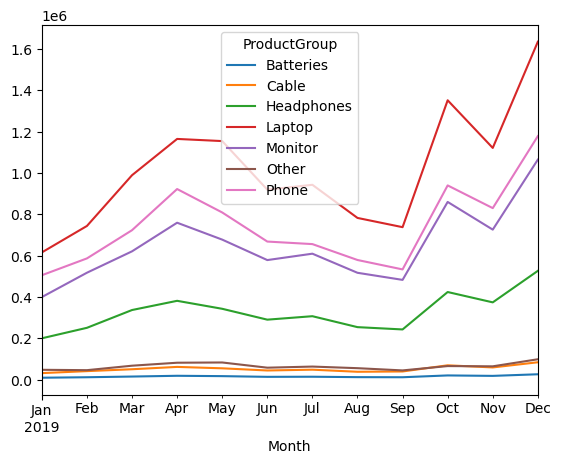

In [288]:
pd.pivot_table(df,values='Total Sales',index='Month',columns='ProductGroup',aggfunc='sum').plot()

In [291]:
df.groupby('Product').sum(numeric_only=True)['Total Sales'].sort_values(ascending=False).head(5)

Product
Macbook Pro Laptop       8037600.00
iPhone                   4794300.00
ThinkPad Laptop          4129958.70
Google Phone             3319200.00
27in 4K Gaming Monitor   2435097.56
Name: Total Sales, dtype: float64

In [292]:
df['Flag4m']=0

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/2856907347.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Flag4m']=0


In [293]:
df.sample(5)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,zipcode,ProductGroup,Total Sales,Flag4m
276,150765,AA Batteries (4-pack),1,3.84,2019-02-13 20:53:00,"750 Madison St, Seattle, WA 98101",2019-02-01,98101,Batteries,3.84,0
2990,298519,Lightning Charging Cable,1,14.95,2019-12-04 13:56:00,"703 North St, San Francisco, CA 94016",2019-12-01,94016,Cable,14.95,0
2290,212095,iPhone,1,700.00,2019-06-17 17:30:00,"877 Lake St, Atlanta, GA 30301",2019-06-01,30301,Phone,700.00,0
2125,238712,Bose SoundSport Headphones,1,99.99,2019-08-31 19:40:00,"324 Sunset St, Portland, OR 97035",2019-08-01,97035,Headphones,99.99,0
20569,315319,Apple Airpods Headphones,1,150.00,2019-12-07 23:02:00,"560 North St, Austin, TX 73301",2019-12-01,73301,Headphones,150.00,0


In [294]:
df.loc[df['Month']=='2019-12-01','flag4m']=1
df.loc[df['Month']=='2019-11-01','flag4m']=1
df.loc[df['Month']=='2019-10-01','flag4m']=1
df.loc[df['Month']=='2019-09-01','flag4m']=1

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3601/381495307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df['Month']=='2019-12-01','flag4m']=1


In [295]:
df4m=df[df['flag4m']==1]

In [299]:
print('Listado de ventas por producto en los últimos 4 meses')
print('-----------------------------------------------------')
df4m.groupby('Product').sum(numeric_only=True)['Total Sales'].sort_values(ascending=False).head(10)

Listado de ventas por producto en los últimos 4 meses
-----------------------------------------------------


Product
Macbook Pro Laptop           3224900.00
iPhone                       1880200.00
ThinkPad Laptop              1623983.76
Google Phone                 1288200.00
27in 4K Gaming Monitor        992134.56
Apple Airpods Headphones      934650.00
34in Ultrawide Monitor        930595.51
Flatscreen TV                 583500.00
Bose SoundSport Headphones    537046.29
27in FHD Monitor              443520.43
Name: Total Sales, dtype: float64

<Axes: xlabel='Product'>

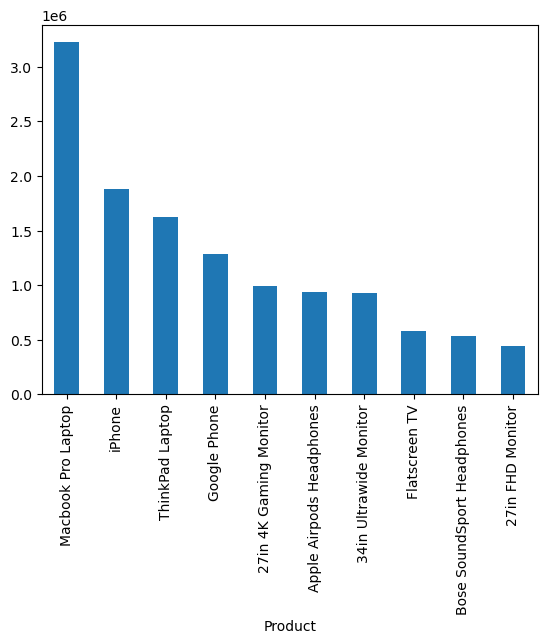

In [301]:
df4m.groupby('Product').sum(numeric_only=True)['Total Sales'].sort_values(ascending=False).head(10).plot.bar()